# S6E8: why gaming_hours helps but adds nothing new

**`gaming_hours` carries no signal about the target that survives conditioning. Inside twelve cells of
fixed screen time and social media it averages an AUC of 0.499 and cannot hold a sign. Added to the
model it is still worth +0.00322, against a seed-to-seed spread of 0.00007.** Both of those are measured
here, and they are not a contradiction. Working out why changes what is worth doing this month.

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin) · [Playground Series S6E8](https://www.kaggle.com/competitions/playground-series-s6e8)*

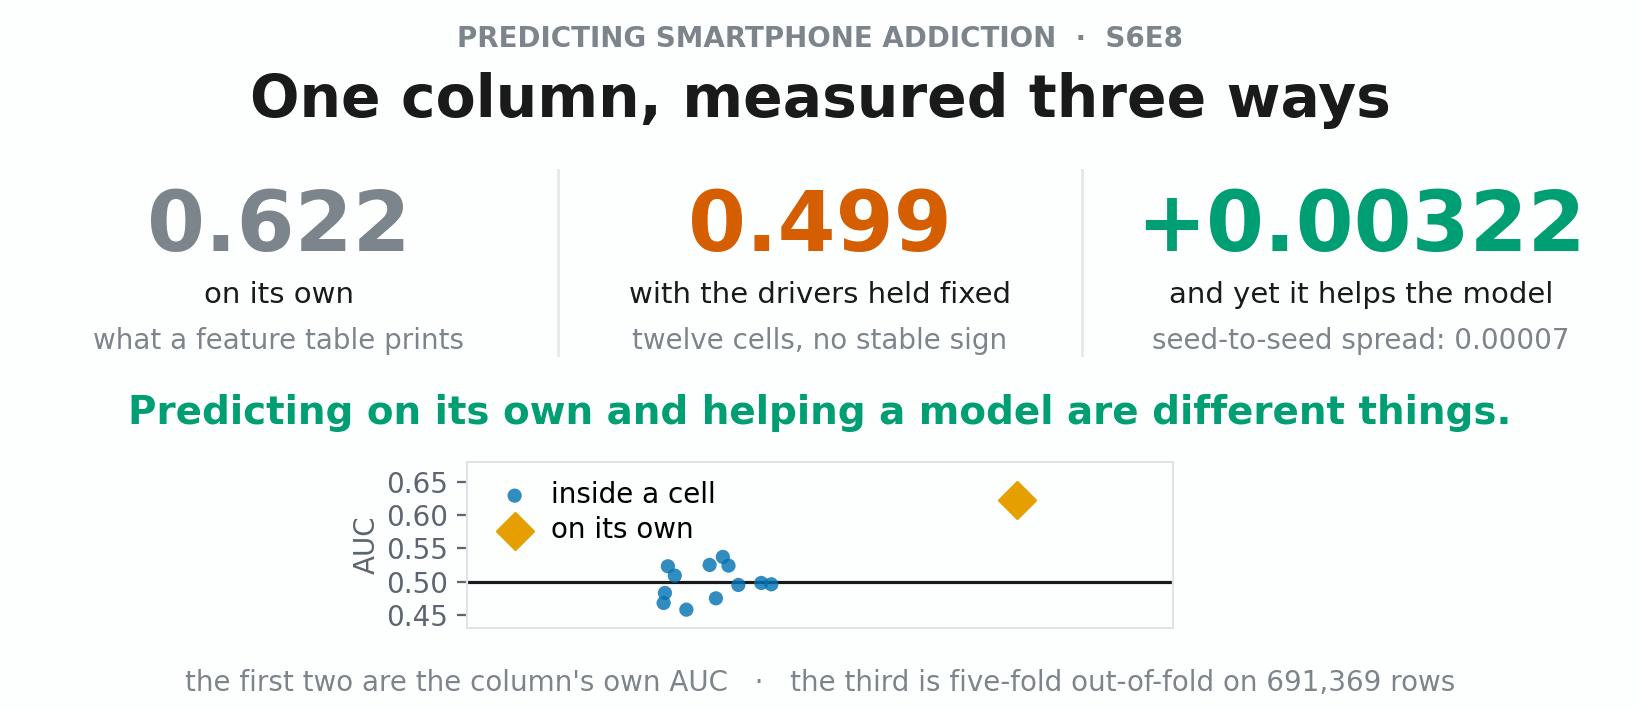

*Budget several hours end to end on a Kaggle CPU kernel; the two ablation sections, the reference
model in section 9 and the library work in sections 10 and 11 are where the time goes. Code and every
measurement script are in
[dmagog/kaggle-notebooks](https://github.com/dmagog/kaggle-notebooks).*

## What you'll take away

- **A control you can run on any tabular competition in four lines**, plus a worked example of it
  giving a right answer to a question I then asked wrongly. Single-feature AUC and conditional AUC
  disagree here about which columns to trust, and the ablation agrees with neither.
- **Why the marginal table is inflated in this dataset specifically.** The generator that made these
  rows built a correlation structure the source file does not have. It is measurable in both
  directions, and it lifts two columns into the middle of a ranking they have not earned.
- **One region where P(addicted) falls as screen time rises.** It survives a split-half check, and it
  makes a monotone constraint, a one-line and obviously reasonable idea, cost you score.
- **A drift alarm that you can safely ignore, with the measurement that proves it.** Adversarial
  validation separates train from test here. All of it sits in the missing-value patterns, and those
  say nothing about the target.
- **One engineered feature that actually pays**, in a competition where almost none do, and the reason
  it works where other arithmetic on the same columns does nothing.
- **A leak-free five-fold baseline** with out-of-fold predictions and a validated submission, so a
  fork starts from working plumbing instead of from scratch.
- **What actually happened to the other seven boards of this season**, both halves of each attached
  and computed here rather than remembered: three erased their public top ten, and both rulers I
  tried to forecast with die on the data, one of them under a control I had built wrongly.

## Contents

1. [The task and the data contract](#1.-The-task-and-the-data-contract)
2. [The signal atlas, the way everyone prints it](#2.-The-signal-atlas,-the-way-everyone-prints-it)
3. [The control that breaks it](#3.-The-control-that-breaks-it)
4. [The ablation disagrees with the control](#4.-The-ablation-disagrees-with-the-control)
   - [4c. Most of the other half, found by someone else](#4c.-Most-of-the-other-half,-found-by-someone-else)
5. [Where the extra signal came from](#5.-Where-the-extra-signal-came-from)
6. [The region where more screen time means less addiction](#6.-The-region-where-more-screen-time-means-less-addiction)
7. [Missingness tells you nothing about the target](#7.-Missingness-tells-you-nothing-about-the-target)
8. [A leak-free baseline and a submission](#8.-A-leak-free-baseline-and-a-submission)
9. [What a weak baseline does and does not inflate](#9.-What-a-weak-baseline-does-and-does-not-inflate)
10. [The blend, taken apart](#10.-The-blend,-taken-apart)
11. [What the leaderboard is measuring today](#11.-What-the-leaderboard-is-measuring-today)
12. [What seven finished boards say](#12.-What-seven-finished-boards-say)
13. [Design choices and limitations](#13.-Design-choices-and-limitations)
14. [What to read next](#14.-What-to-read-next)
15. [Credits](#Credits)

In [1]:
import os, glob, random, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
warnings.filterwarnings("ignore")

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); os.environ["PYTHONHASHSEED"] = str(s)
seed_everything()

# The Kaggle base image moves and silently changes results, so pin what produced these numbers.
import lightgbm, sklearn, sys
print(f"python {sys.version.split()[0]}  numpy {np.__version__}  pandas {pd.__version__}  "
      f"lightgbm {lightgbm.__version__}  sklearn {sklearn.__version__}")

# Okabe-Ito. The three categorical slots carry identity and clear a colourblind-safety
# check (worst adjacent pair, deuteranopia and protanopia, is well past the usual floor);
# GREY is reserved for reference marks and never stands for a series. Labels wear ink,
# never the series colour, so identity always comes from the mark beside the text.
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#E69F00", "#009E73", "#888888"
INK, MUTED = "#222222", "#555555"
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

# A marker with a surface ring, so overlapping points stay separable.
def dot(ax, x, y, color, size=90, z=4):
    ax.scatter(x, y, s=size, color=color, zorder=z, edgecolor="white", linewidth=1.6)

# A legend handle. Legends live outside the data area; inside, they read as data.
def key(color, marker=True):
    return (Line2D([], [], marker="o", ls="", color=color, markersize=8,
                   markeredgecolor="white", markeredgewidth=1.4) if marker
            else Line2D([], [], color=color, lw=2.2))

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": .25,
                     "grid.linestyle": "-", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

def find(pattern, *fallbacks):
    for hit in glob.glob(pattern, recursive=True):
        return hit
    for f in fallbacks:
        if os.path.exists(f):
            return f
    raise FileNotFoundError(pattern)

DATA = os.path.dirname(find("/kaggle/input/**/train.csv", "data/train.csv"))
train = pd.read_csv(os.path.join(DATA, "train.csv"))
test  = pd.read_csv(os.path.join(DATA, "test.csv"))

TARGET, ID = "addicted_label", "id"
NUM = ["age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
       "work_study_hours", "sleep_hours", "notifications_per_day",
       "app_opens_per_day", "weekend_screen_time"]
CAT = ["gender", "stress_level", "academic_work_impact"]
FEATURES = NUM + CAT
DST, SM = "daily_screen_time_hours", "social_media_hours"

print(f"train {train.shape}   test {test.shape}   positive rate {train[TARGET].mean():.4f}")

python 3.12.13  numpy 2.0.2  pandas 2.3.3  lightgbm 4.6.0  sklearn 1.6.1
train (691369, 14)   test (296302, 13)   positive rate 0.7094


## 1. The task and the data contract

One row is one person. The target `addicted_label` is binary and the metric is **ROC AUC**, which
only cares about ranking: whether addicted people get higher scores than non-addicted ones. Nothing
below tunes a decision threshold, because the metric never looks at one.

Two facts to keep in mind for the rest of the notebook. The classes are unbalanced in the mild
direction, about seven positives to three negatives, which is comfortable for AUC. And every feature
column has missing values, between 4% and 20% of rows, which is unusual for this series and turns
out to matter less than it looks (section 7).

In [2]:
contract = pd.DataFrame({
    "dtype":   train[FEATURES].dtypes.astype(str),
    "missing %": (train[FEATURES].isna().mean() * 100).round(2),
    "distinct": train[FEATURES].nunique(),
    "min":     [train[c].min() if c in NUM else "" for c in FEATURES],
    "max":     [train[c].max() if c in NUM else "" for c in FEATURES],
    "levels":  ["" if c in NUM else ", ".join(map(str, sorted(train[c].dropna().unique()))) for c in FEATURES],
})
print(f"rows: train {len(train):,}   test {len(test):,}")
print(f"P(addicted) = {train[TARGET].mean():.4f}")
contract

rows: train 691,369   test 296,302
P(addicted) = 0.7094


,dtype,missing %,distinct,min,max,levels
age,float64,4.18,18,18.0,35.0,
daily_screen_time_hours,float64,13.86,1389,0.5,15.0,
social_media_hours,float64,19.38,721,0.0,8.0,
gaming_hours,float64,18.34,401,0.0,4.0,
work_study_hours,float64,7.45,600,0.0,6.0,
sleep_hours,float64,6.43,451,4.5,9.0,
notifications_per_day,float64,9.78,231,20.0,250.0,
app_opens_per_day,float64,11.67,166,15.0,180.0,
weekend_screen_time,float64,16.21,1437,0.51,17.56,
gender,object,4.20,3,,,"Female, Male, Other"


## 2. The signal atlas, the way everyone prints it

The standard first move on a tabular competition is to score every feature on its own and rank them.
It is a good move. The table below does exactly that: for each column, the AUC it reaches by itself,
computed only on rows where that column is observed.

Read it the way you normally would, then hold on to the number for `gaming_hours` and
`work_study_hours`.

In [3]:
from sklearn.metrics import roc_auc_score

def auc_sym(y, x):
    # AUC that ignores direction, so a feature ranking backwards is not called useless.
    a = roc_auc_score(y, x)
    return max(a, 1 - a)

rows = []
for c in NUM:
    o = train[[c, TARGET]].dropna()
    rows.append({"feature": c, "single-feature AUC": auc_sym(o[TARGET], o[c]), "n": len(o)})
for c in CAT:
    o = train[[c, TARGET]].dropna()
    # in-sample, so this is generous on purpose
    enc = o[c].map(o.groupby(c)[TARGET].mean())
    rows.append({"feature": c, "single-feature AUC": auc_sym(o[TARGET], enc), "n": len(o)})

atlas = (pd.DataFrame(rows).sort_values("single-feature AUC", ascending=False)
           .reset_index(drop=True))
atlas["single-feature AUC"] = atlas["single-feature AUC"].round(4)
atlas

,feature,single-feature AUC,n
0,daily_screen_time_hours,0.8896,595515
1,weekend_screen_time,0.8810,579306
2,social_media_hours,0.8578,557374
3,work_study_hours,0.6549,639851
4,gaming_hours,0.6220,564548
5,app_opens_per_day,0.5409,610659
6,sleep_hours,0.5270,646889
7,gender,0.5120,662335
8,notifications_per_day,0.5079,623785
9,stress_level,0.5031,636221


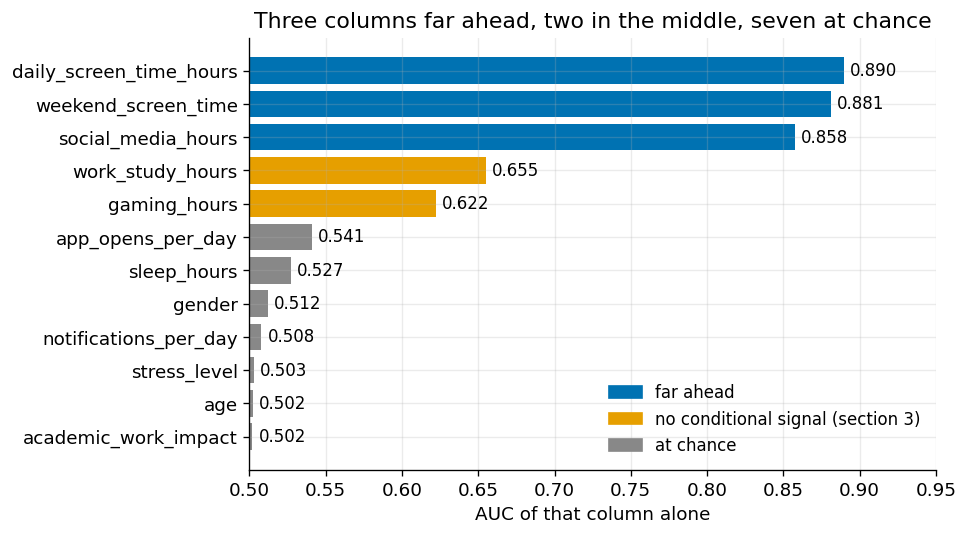

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
a = atlas.sort_values("single-feature AUC")
colours = [ORANGE if f in ("gaming_hours", "work_study_hours") else
           (BLUE if v >= .8 else GREY) for f, v in zip(a.feature, a["single-feature AUC"])]
ax.barh(a.feature, a["single-feature AUC"] - .5, left=.5, color=colours)
ax.axvline(.5, color="k", lw=1)
ax.set_xlim(.5, .95); ax.set_xlabel("AUC of that column alone")
ax.set_title("Three columns far ahead, two in the middle, seven at chance")
for f, v in zip(a.feature, a["single-feature AUC"]):
    ax.text(v + .004, f, f"{v:.3f}", va="center", fontsize=10)
# Bottom right is empty for any data here: the short bars sit at the bottom.
# Placed in axes coordinates so it can never land on top of a bar or the axis.
from matplotlib.patches import Patch, Rectangle
# All three colours get a key: colour is never the only thing carrying the grouping,
# but an unexplained palette still makes the reader guess.
ax.legend(handles=[Patch(color=BLUE, label="far ahead"),
                   Patch(color=ORANGE, label="no conditional signal (section 3)"),
                   Patch(color=GREY, label="at chance")],
          loc="lower right", frameon=False, fontsize=10)
fig.tight_layout(); plt.show()

Daily screen time, weekend screen time and social media hours sit between 0.85 and 0.89, no surprise
for a dataset about phone use, and seven more sit between 0.50 and 0.55. (Every column clears 0.50
here because the AUC is symmetrised, so a column that ranks backwards is not reported as useless;
0.50 is the floor, not a pass mark.)

The interesting pair is `work_study_hours` and `gaming_hours`, sitting in the middle of the table at
around 0.65 and 0.62. Those are not large numbers, but they are not noise-level either, and a feature
zoo built on this table would happily use both.

## 3. The control that breaks it

A single-feature AUC answers: *if this column were all I had, how well could I rank?* That is rarely
the question you care about. The question you care about is: *given what the strong columns already
tell me, does this one add anything?*

The two answers can differ, and the way to find out is to hold the strong columns fixed. Four lines,
on any tabular problem:

    for lo_a, hi_a in bands_a:            # a grid over the columns you trust
        for lo_b, hi_b in bands_b:
            cell = df[df[a].between(lo_a, hi_a) & df[b].between(lo_b, hi_b)]
            print(len(cell), roc_auc_score(cell[target], cell[suspect]))

Below, every cell fixes daily screen time to a one-hour band and social media hours to a half-hour
band, then measures the remaining columns inside that cell. If a column carries its own signal, it
keeps it here. If it was only riding along on the strong columns, it drops to 0.50.

One detail matters: the AUC below is **signed**, not symmetrised. Above 0.50 means more of the column
goes with being addicted; below 0.50 means the opposite. A column with real signal keeps the same
side across cells. A column with none wanders.

In [5]:
obs = train[[DST, SM, "gaming_hours", "work_study_hours", "sleep_hours",
             "app_opens_per_day", TARGET]].dropna()

cells_out = []
for lo_d in [4, 5, 6, 7]:
    for lo_s, hi_s in [(1.0, 1.5), (1.5, 2.0), (2.0, 2.5)]:
        c = obs[(obs[DST] > lo_d) & (obs[DST] <= lo_d + 1) &
                (obs[SM] > lo_s) & (obs[SM] <= hi_s)]
        y = c[TARGET].to_numpy()
        if len(c) < 500 or y.min() == y.max():
            continue
        cells_out.append({
            "daily": f"({lo_d}, {lo_d+1}]", "social": f"({lo_s}, {hi_s}]", "n": len(c),
            "P(y=1)": round(y.mean(), 3),
            "gaming": round(roc_auc_score(y, c.gaming_hours), 3),
            "work_study": round(roc_auc_score(y, c.work_study_hours), 3),
            "sleep": round(roc_auc_score(y, c.sleep_hours), 3),
            "app_opens": round(roc_auc_score(y, c.app_opens_per_day), 3),
        })
cond = pd.DataFrame(cells_out)
print(f"cells: {len(cond)}   rows covered: {cond.n.sum():,}")
print("\nmean signed AUC inside a cell (0.500 = no signal):")
print(cond[["gaming", "work_study", "sleep", "app_opens"]].mean().round(3).to_string())
print("\ncells below 0.500, i.e. the column points the other way:")
print((cond[["gaming", "work_study", "sleep", "app_opens"]] < .5).sum().to_string()
      + f"   out of {len(cond)}")
cond

cells: 12   rows covered: 87,496

mean signed AUC inside a cell (0.500 = no signal):
gaming        0.499
work_study    0.507
sleep         0.524
app_opens     0.527

cells below 0.500, i.e. the column points the other way:
gaming        7
work_study    4
sleep         0
app_opens     0   out of 12


,daily,social,n,P(y=1),gaming,work_study,sleep,app_opens
0,"(4, 5]","(1.0, 1.5]",10443,0.156,0.471,0.449,0.530,0.523
1,"(4, 5]","(1.5, 2.0]",10085,0.468,0.458,0.526,0.522,0.503
2,"(4, 5]","(2.0, 2.5]",5165,0.624,0.494,0.516,0.527,0.517
3,"(5, 6]","(1.0, 1.5]",7526,0.117,0.497,0.497,0.531,0.529
4,"(5, 6]","(1.5, 2.0]",9484,0.356,0.479,0.481,0.515,0.509
5,"(5, 6]","(2.0, 2.5]",8287,0.623,0.478,0.540,0.526,0.514
6,"(6, 7]","(1.0, 1.5]",5084,0.271,0.538,0.505,0.518,0.538
7,"(6, 7]","(1.5, 2.0]",7408,0.388,0.509,0.508,0.534,0.550
8,"(6, 7]","(2.0, 2.5]",8858,0.639,0.499,0.549,0.524,0.531
9,"(7, 8]","(1.0, 1.5]",3326,0.505,0.524,0.501,0.521,0.535


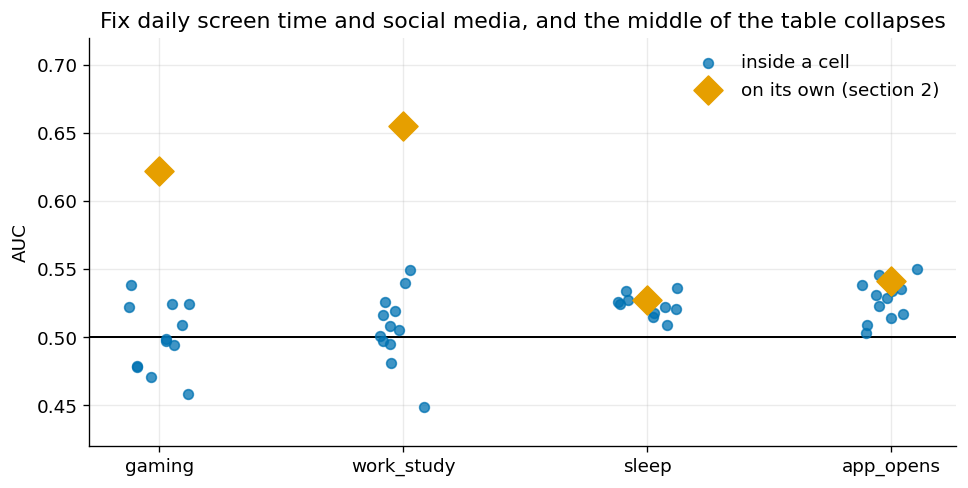

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
FULL = {"gaming": "gaming_hours", "work_study": "work_study_hours",
        "sleep": "sleep_hours", "app_opens": "app_opens_per_day"}
cols = list(FULL)
marg = {k: float(atlas.loc[atlas.feature == v, "single-feature AUC"].iloc[0])
        for k, v in FULL.items()}
for i, c in enumerate(cols):
    ax.scatter(np.full(len(cond), i) + np.random.uniform(-.13, .13, len(cond)), cond[c],
               s=34, color=BLUE, alpha=.75, zorder=3, label="inside a cell" if i == 0 else None)
    ax.scatter([i], [marg[c]], s=150, marker="D", color=ORANGE, zorder=4,
               label="on its own (section 2)" if i == 0 else None)
ax.axhline(.5, color="k", lw=1.2)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
ax.set_ylabel("AUC"); ax.set_ylim(.42, .72)
ax.set_title("Fix daily screen time and social media, and the middle of the table collapses")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout(); plt.show()

`gaming_hours` averages almost exactly 0.500 across the cells and cannot decide which side of 0.500 it
belongs on. `work_study_hours` does the same. Both looked informative in section 2, and neither
survives conditioning.

The more interesting half of the table is the other two columns. `sleep_hours` and `app_opens_per_day`
sit just below the pair in the section 2 ranking, at the top of the block it calls chance, and they are
the only two that hold the same side of 0.500 in every single cell. The effect is small, but it is consistent in a way the two larger numbers
are not.

So the marginal table does not merely inflate. **It reorders.** It puts `work_study_hours` at 0.65,
well above `sleep_hours` at 0.53, and conditioning reverses that: the column ranked higher is the one
that turns out to be noise. If you were picking features to build on from the section 2 ranking, it
would have pointed you at the wrong end of its own list.

A fair objection: the cells are one hour wide in daily screen time, so some variation is left inside
them, and leftover variation could still be doing the work. Note which way that cuts. Residual
confounding inside a cell would *manufacture* apparent signal, not destroy it. Finding 0.500 despite
it is the conservative outcome, not the fragile one. The next section removes the objection entirely
by putting the question to a model.

## 4. The ablation disagrees with the control

Conditioning is an argument. The metric is the judge. This section gives a model a set of columns,
takes some away, and reports what the competition metric does. Every setting inside one seed shares its
folds, so the comparisons are paired; the fold split is redrawn for each new seed, so the spread below
already contains resplit noise as well as model noise. Three seeds, because one split is not a measurement.

Two comparisons carry the section. Adding `gaming_hours` and `work_study_hours` on top of the three
screen-time columns is the direct test of section 3. Dropping those three and keeping the other nine
shows what the rest of the table is worth on its own.

In [7]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

THREE = [DST, SM, "weekend_screen_time"]
SETS = {
    "the three screen columns":   THREE,
    "three + gaming":             THREE + ["gaming_hours"],
    "three + gaming + work":      THREE + ["gaming_hours", "work_study_hours"],
    "all twelve":                 FEATURES,
    "all twelve minus the three": [c for c in FEATURES if c not in THREE],
}
PARAMS = dict(objective="binary", metric="auc", learning_rate=.05, num_leaves=63,
              min_data_in_leaf=200, feature_fraction=.9, bagging_fraction=.9,
              bagging_freq=1, verbosity=-1)
ROUNDS, SEEDS = 400, [0, 1, 2]

Xall = train[FEATURES].copy()
for c in CAT:
    Xall[c] = Xall[c].astype("category")
y = train[TARGET].to_numpy()

def oof_auc(feats, seed):
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    oof = np.zeros(len(y))
    for tr_i, va_i in skf.split(Xall, y):
        ds = lgb.Dataset(Xall.iloc[tr_i][feats], y[tr_i])
        m = lgb.train({**PARAMS, "seed": seed}, ds, num_boost_round=ROUNDS)
        oof[va_i] = m.predict(Xall.iloc[va_i][feats])
    return roc_auc_score(y, oof)

abl = {name: [oof_auc(f, s) for s in SEEDS] for name, f in SETS.items()}
tab = pd.DataFrame(abl, index=[f"seed {s}" for s in SEEDS]).T
seed_cols = list(tab.columns)
tab["mean"]     = tab[seed_cols].mean(axis=1)
tab["spread"]   = tab[seed_cols].max(axis=1) - tab[seed_cols].min(axis=1)
tab["features"] = [len(f) for f in SETS.values()]
tab.round(5)

,seed 0,seed 1,seed 2,mean,spread,features
the three screen columns,0.93600,0.93597,0.93604,0.93600,0.00006,3
three + gaming,0.93922,0.93919,0.93925,0.93922,0.00007,4
three + gaming + work,0.94304,0.94301,0.94306,0.94304,0.00006,5
all twelve,0.96213,0.96216,0.96219,0.96216,0.00006,12
all twelve minus the three,0.85859,0.85864,0.85869,0.85864,0.00010,9


In [8]:
base = tab.loc["the three screen columns", "mean"]
delta = (tab["mean"] - base).round(5).rename("vs the three screen columns")
print(f"reference: the three screen columns = {base:.5f} OOF AUC\n")
display(delta.to_frame("vs the three screen columns").round(5))

# The two numbers the title block and the card at the top quote, printed here so both halves
# of that ratio come out of this run rather than out of two.
HEAD = ["the three screen columns", "three + gaming"]
print(f"\nheadline: gaming_hours alone is worth {tab.loc[HEAD[1], 'mean'] - base:+.5f}, "
      f"against a seed-to-seed spread of {tab.loc[HEAD, 'spread'].max():.5f}")
print(f"seed-to-seed spread at its widest over all {len(tab)} settings: {tab['spread'].max():.5f}")

reference: the three screen columns = 0.93600 OOF AUC



,vs the three screen columns
the three screen columns,0.00000
three + gaming,0.00322
three + gaming + work,0.00703
all twelve,0.02616
all twelve minus the three,-0.07736



headline: gaming_hours alone is worth +0.00322, against a seed-to-seed spread of 0.00007
seed-to-seed spread at its widest over all 5 settings: 0.00010


Read the deltas against the spread column, and the section does not say what section 3 predicted it
would say.

`gaming_hours` and `work_study_hours` carry no signal you can find by conditioning, and adding them
is worth many times the seed-to-seed noise of the same model. Both measurements are correct. I wrote
the first one down expecting it to settle the second, and it does not.

### 4b. The two answers are to different questions

A column can matter to a model without predicting the target. The clue is in section 1: daily screen
time is missing on about 14% of rows and social media hours on about 19%. On roughly a quarter of the
data, the model does not have the columns that decide the label.

Section 5 shows a budget constraint in this data. Daily screen time is never less than social
plus gaming plus work/study, with zero exceptions in over four hundred thousand rows. That makes
`gaming_hours` and `work_study_hours` informative about *the missing values of the columns that do
predict*, without being informative about the label itself.

If that is the mechanism, the gain has nothing left to do on rows where both drivers are present.
Same schedule and the same seeds; the folds are redrawn because the row set changes.

In [9]:
both = train[DST].notna() & train[SM].notna()
print(f"rows with both drivers observed: {both.sum():,} of {len(train):,} "
      f"({both.mean():.1%})\n")

sub_train = train[both].reset_index(drop=True)
Xsub = sub_train[FEATURES].copy()
for c in CAT:
    Xsub[c] = Xsub[c].astype("category")
ysub = sub_train[TARGET].to_numpy()

def oof_auc_on(X, yy, feats, seed):
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    p = np.zeros(len(yy))
    for tr_i, va_i in skf.split(X, yy):
        m = lgb.train({**PARAMS, "seed": seed},
                      lgb.Dataset(X.iloc[tr_i][feats], yy[tr_i]), num_boost_round=ROUNDS)
        p[va_i] = m.predict(X.iloc[va_i][feats])
    return roc_auc_score(yy, p)

pair = ["the three screen columns", "three + gaming + work"]
rows = []
for label, (X_, y_) in [("all rows", (Xall, y)), ("both drivers observed", (Xsub, ysub))]:
    sc = {k: np.mean([oof_auc_on(X_, y_, SETS[k], s) for s in SEEDS[:2]]) for k in pair}
    rows.append({"rows used": label, **{k: round(v, 5) for k, v in sc.items()},
                 "gain from gaming + work": round(sc[pair[1]] - sc[pair[0]], 5)})
pd.DataFrame(rows).set_index("rows used")

rows with both drivers observed: 502,260 of 691,369 (72.6%)



,the three screen columns,three + gaming + work,gain from gaming + work
rows used,,,
all rows,0.93599,0.94302,0.00704
both drivers observed,0.94901,0.95281,0.00380


About half the gain is imputation. Removing the rows with a missing driver removes roughly 46% of what
`gaming_hours` and `work_study_hours` were worth, which is a large share to attribute to one mechanism
and nowhere near all of it.

I am not going to round that up into a clean story. **When this notebook first went up, nothing in it
explained the remaining half.** Section 4c is what happened next. Either way the honest reading of
section 3 has to shrink to fit: the twelve cells there cover 17% of the
rows where both drivers are observed, inside a window running from 4 to 8 hours of daily screen time
and 1 to 2.5 of social media. Outside that window the control never looked. A gradient booster looks
everywhere, and it is finding something there that twelve cells in the middle of the distribution
cannot see.

So the defensible claims are narrower than the ones I set out to make. Inside the region section 3
covers the marginal table has the ordering backwards; both columns are still worth keeping, and about
half of why is that they reconstruct drivers the generator left recoverable by exact arithmetic.
**Reconstruction is a lever.** I also wrote here that feature engineering on these columns probably was
not one, and section 4c is why that half of the sentence did not survive the week.

If you can account for the other half, I would like to see it, and I will add it here with credit.

### 4c. Most of the other half, found by someone else

Two days after that paragraph went up, [Dariush Afshar](https://www.kaggle.com/dariushafshar) answered
a question from [Muhammad Faheem](https://www.kaggle.com/muhammadf4h33m) in
[this thread](https://www.kaggle.com/competitions/playground-series-s6e8/discussion/732223) with a
feature I had not tried:

    other_screen = daily_screen_time - (social_media + gaming + work_study)

The screen time a person spends on nothing the dataset names. It rests on the budget constraint from
section 5, so it only exists where all four columns do.

This is what my section 3 control could not have found, and the reason is structural rather than bad
luck. That control measures one column at a time inside a cell. The residual is a function of three
columns at once, and no amount of measuring `gaming_hours` on its own will surface it. A control that
holds the strong features fixed tells you whether a column carries signal alone. It says nothing about
what the column carries in combination.

The measurement below takes the feature three ways: on its own, as a replacement for the two columns whose
gain section 4b could not explain, and added to the full model.

In [10]:
RESID = "other_screen"
resid_all = train[DST] - (train[SM] + train["gaming_hours"] + train["work_study_hours"])
ok = resid_all.notna()
print(f"computable on {ok.sum():,} of {len(train):,} rows ({ok.mean():.1%})")
print(f"rows where it comes out negative: {int((resid_all < -1e-9).sum())}")
print(f"standalone AUC where it exists:   "
      f"{roc_auc_score(train[TARGET][ok], resid_all[ok]):.4f}\n")

Xr = Xall.copy(); Xr[RESID] = resid_all
Xsub_r = Xsub.copy(); Xsub_r[RESID] = resid_all[both].to_numpy()
GW = ["gaming_hours", "work_study_hours"]

diag = []
for label, feats in [("three screen columns", THREE),
                     ("three + gaming + work", THREE + GW),
                     ("three + residual", THREE + [RESID])]:
    diag.append({"features on complete rows": label,
                 "OOF AUC": np.mean([oof_auc_on(Xsub_r, ysub, feats, s)
                            for s in SEEDS[:2]])})
diag = pd.DataFrame(diag).set_index("features on complete rows")
diag["vs three"] = diag["OOF AUC"] - diag["OOF AUC"].iloc[0]
share = diag["vs three"].iloc[2] / diag["vs three"].iloc[1]
print(diag.round(5).to_string())
print(f"\nthe residual alone recovers {share:.0%} of what gaming + work_study "
      f"are worth here\n")

full = [oof_auc_on(Xr, y, FEATURES, s) for s in SEEDS]
plus = [oof_auc_on(Xr, y, FEATURES + [RESID], s) for s in SEEDS]
gain = np.array(plus) - np.array(full)
print(f"all twelve             {np.mean(full):.5f}   spread {max(full)-min(full):.5f}")
print(f"all twelve + residual  {np.mean(plus):.5f}   spread {max(plus)-min(plus):.5f}")
print(f"paired gain per seed   {np.round(gain, 5).tolist()}")
print(f"mean gain              {gain.mean():+.5f}")

computable on 421,427 of 691,369 rows (61.0%)
rows where it comes out negative: 0
standalone AUC where it exists:   0.7649

                           OOF AUC  vs three
features on complete rows                   
three screen columns       0.94901   0.00000
three + gaming + work      0.95281   0.00380
three + residual           0.95142   0.00242

the residual alone recovers 64% of what gaming + work_study are worth here

all twelve             0.96216   spread 0.00006
all twelve + residual  0.96280   spread 0.00004
paired gain per seed   [0.00068, 0.00062, 0.00061]
mean gain              +0.00064


On its own the residual lands at about 0.76. That puts it fourth in the section 2 table, behind the
three screen-time columns and ahead of everything else, including `gaming_hours` and `work_study_hours`
at 0.62 and 0.65. Two of its four inputs are the columns section 3 showed carry nothing alone. Combining
them with the column that carries the most produces something that outranks either of them.

So the open question from section 4b is now mostly closed, and not by me. On the rows where both
drivers are present, the residual on its own recovers about two thirds of what `gaming_hours` and
`work_study_hours` were worth. They were never carrying signal about addiction. They were carrying
one arithmetic fact about a column that does.

A third of that gain is still unaccounted for, and I would rather leave that written down than round
it away.

The practical half matters more than the diagnostic half. Added to the full twelve-column model the
residual is worth roughly ten times the seed-to-seed spread, and it moves the same direction on every
seed. That is a real feature in a competition where most engineered features do nothing, which makes
it a direct answer to the question Muhammad Faheem asked in that thread: yes, feature engineering can
move this dataset, but not by combining columns the trees can already split on. It moves when a
feature encodes something about how the data was made.

Credit where it belongs. The constraint underneath this was published first by
ryota517, whose notebook has since been removed from Kaggle. Turning it
into a feature and measuring it is Dariush Afshar's. What is mine is the check that it explains the
hole section 4b left, and the numbers above.

## 5. Where the extra signal came from

If `gaming_hours` carries no conditional signal, why does it reach 0.62 on its own? Something has to
correlate it with the columns that do carry signal. This section finds that something.

The data page says these rows were inspired by a Smartphone Addiction Prediction Dataset. The dataset
it links to is not publicly readable. A separate public dataset,
[Smartphone Usage & Addiction Prediction](https://www.kaggle.com/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction), carries the same twelve predictors and the
same target plus three extra columns.

**I cannot prove it is the source**, and I am not going to write as though I can. Two independent
uploads of that file are byte-identical, which tells you they came from a common ancestor, not that
the ancestor is this competition's. ryota517 reached the same fork in the road first and
called the file a *candidate mirror*; that is the right name and I use it here. Everything below is
a comparison between two files, and the conclusion is re-checked on competition data alone before it
is used for anything.

In [11]:
MIRROR = find("/kaggle/input/**/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv",
              "mirror/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
mirror = pd.read_csv(MIRROR)
print(f"candidate mirror: {mirror.shape}, P(addicted) = {mirror[TARGET].mean():.4f}")
print(f"columns it has that the competition does not: "
      f"{sorted(set(mirror.columns) - set(train.columns))}")

candidate mirror: (7500, 16), P(addicted) = 0.7077
columns it has that the competition does not: ['addiction_level', 'transaction_id', 'user_id']


### 5a. The mirror's label is a rule

Before comparing correlations, look at how the label behaves in the mirror. It is not a graded score
with a fuzzy boundary. It is a threshold on two columns, with a coin flip in between.

In [12]:
ym = mirror[TARGET].to_numpy()
dm, sm_ = mirror[DST].to_numpy(), mirror[SM].to_numpy()
fires = (dm > 8) | (sm_ > 4)
low   = (dm <= 6) & ~fires
band  = (dm > 6) & ~fires

for label, mask in [("daily > 8 or social > 4", fires),
                    ("daily <= 6 and social <= 4", low),
                    ("6 < daily <= 8, social <= 4", band)]:
    print(f"P(y=1 | {label:<28}) = {ym[mask].mean():.4f}   n = {mask.sum():,}")

print(f"\nrows breaking the first clause: {int(((ym == 0) & fires).sum())}")
print(f"rows breaking the second:       {int(((ym == 1) & low).sum())}")

inband = mirror[band]
corr = (inband[NUM].corrwith(pd.Series(ym[band], index=inband.index))
        .abs().sort_values(ascending=False))
print(f"\ninside the band, largest |correlation| with the label: "
      f"{corr.index[0]} at {corr.iloc[0]:.3f}")

P(y=1 | daily > 8 or social > 4     ) = 1.0000   n = 4,841
P(y=1 | daily <= 6 and social <= 4  ) = 0.0000   n = 1,634
P(y=1 | 6 < daily <= 8, social <= 4 ) = 0.4556   n = 1,025

rows breaking the first clause: 0
rows breaking the second:       0

inside the band, largest |correlation| with the label: sleep_hours at 0.068


Two clauses with no exceptions in either direction, and 1,025 rows in between, about 14% of the file,
where the label is a coin flip that no column predicts. The thresholds are not perfectly crisp. A handful of rows sit
exactly on 8.00 and 4.00 and split both ways, which looks like a continuous quantity rounded to two
decimals rather than a hard cut. The shape is still unmistakable.

In the mirror, then: two of the twelve shared predictors decide the label and the other ten are decorative.

### 5b. What the generator changed

Now the comparison. Kaggle's synthetic data is produced by a model trained on the source, and models
do not copy, they approximate. Two things changed, and the second one explains section 2.

In [13]:
COMPONENTS = [SM, "gaming_hours", "work_study_hours"]

print("Rule transfer: the mirror's clauses, re-measured on competition data\n")
o = train[[DST, SM, TARGET]].dropna()
yo, do, so = o[TARGET].to_numpy(), o[DST].to_numpy(), o[SM].to_numpy()
f2 = (do > 8) | (so > 4)
comparison = pd.DataFrame({
    "mirror": [ym[fires].mean(), ym[low].mean(), ym[band].mean()],
    "competition": [yo[f2].mean(), yo[~f2 & (do <= 6)].mean(), yo[~f2 & (do > 6)].mean()],
}, index=["daily>8 or social>4", "daily<=6 and social<=4", "the band"]).round(4)
display(comparison)

print("\n\nThe time-allocation constraint: daily >= social + gaming + work_study\n")
for name, df in [("mirror", mirror), ("competition", train)]:
    c = df[[DST] + COMPONENTS].dropna()
    resid = c[DST] - c[COMPONENTS].sum(axis=1)
    print(f"  {name:<13} rows {len(c):>9,}   violations {int((resid < -1e-9).sum()):>8,}"
          f"   median slack {resid.median():+.2f} h")

print("\n\nCorrelation of each component with daily screen time\n")
for name, df in [("mirror", mirror), ("competition", train)]:
    c = df[[DST] + COMPONENTS].dropna()
    cols = "   ".join(f"{k[:12]:<12} {c[DST].corr(c[k]):+.3f}" for k in COMPONENTS)
    print(f"  {name:<13}" + cols)

Rule transfer: the mirror's clauses, re-measured on competition data



,mirror,competition
daily>8 or social>4,1.0000,0.9759
daily<=6 and social<=4,0.0000,0.3253
the band,0.4556,0.6498




The time-allocation constraint: daily >= social + gaming + work_study

  mirror        rows     7,500   violations    4,552   median slack -1.03 h
  competition   rows   421,427   violations        0   median slack +0.75 h


Correlation of each component with daily screen time

  mirror       social_media +0.010   gaming_hours +0.001   work_study_h +0.003
  competition  social_media +0.595   gaming_hours +0.429   work_study_h +0.525


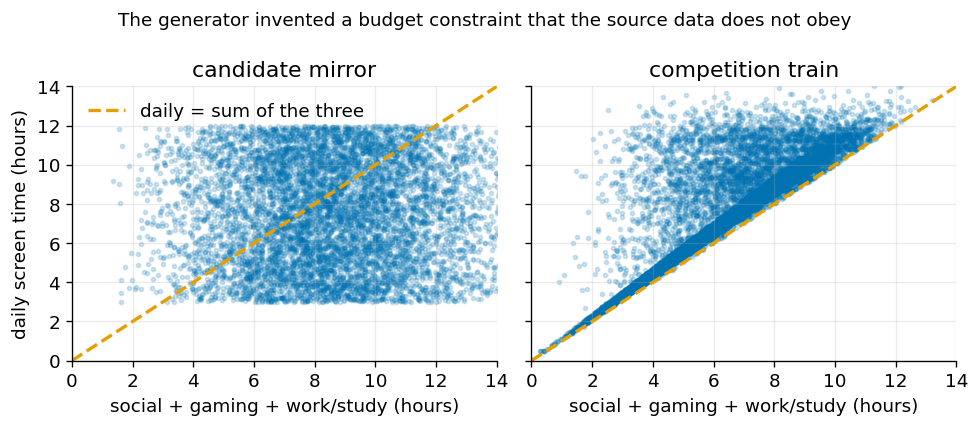

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6), sharex=True, sharey=True)
for ax, (name, df) in zip(axes, [("candidate mirror", mirror), ("competition train", train)]):
    c = df[[DST] + COMPONENTS].dropna()
    c = c.sample(min(12_000, len(c)), random_state=SEED)
    ax.scatter(c[COMPONENTS].sum(axis=1), c[DST], s=6, alpha=.18, color=BLUE, rasterized=True)
    lim = 14
    ax.plot([0, lim], [0, lim], color=ORANGE, ls="--", lw=2, label="daily = sum of the three")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("social + gaming + work/study (hours)")
    ax.set_title(name)
axes[0].set_ylabel("daily screen time (hours)")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("The generator invented a budget constraint that the source data does not obey",
             y=0.98, fontsize=11)
fig.tight_layout(); plt.show()

The left panel scatters through the diagonal: in the mirror, most rows report component hours that
add up to more than the daily total, and the components are uncorrelated with it. The right panel is
a clean wedge with the diagonal as a hard floor.

So the budget constraint is not inherited from the source. It was manufactured during generation, and
with it came correlations of roughly +0.43 to +0.60 between the components and daily screen time,
where the source has essentially zero. ryota517 found this constraint first and called it a generation
fingerprint, which the mirror comparison now confirms from the other side: the fingerprint belongs to
Kaggle's generator, not to whoever wrote the original file.

That is the whole story of section 2. Once `gaming_hours` correlates with daily screen time at +0.43,
it inherits a marginal AUC from a column it has no independent relationship with. The constraint also explains why section 3 has to fix both
strong columns at once rather than one: inside a fixed band of daily screen time, more gaming leaves
less room for social media, so gaming keeps borrowing signal until social media is held too.

The rule itself did not survive intact. The clause that never failed in the mirror holds about 98% of
the time here, and the region that was uniformly negative now runs about a third positive. A hard
threshold came out of the generator as a slope.

## 6. The region where more screen time means less addiction

Plot P(addicted) against daily screen time and you get a clean rising curve. Nobody would question it,
and a reasonable person might decide to help their model along by constraining that relationship to be
monotone. LightGBM makes this a one-line change.

Do it and you lose score. Here is why.

In [15]:
g = train[[DST, SM, TARGET]].dropna()

def wilson(k, n, z=1.96):
    # Wilson score interval: behaves near 0 and 1, where the normal approximation does not.
    p = k / n; d = 1 + z*z/n
    c = p + z*z/(2*n); h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return (c - h)/d, (c + h)/d

EDGES = np.arange(3, 12.1, 1.0)
BANDS = [(1.0, 1.5), (1.5, 2.0), (2.0, 2.5)]

uncond = g.groupby(pd.cut(g[DST], EDGES), observed=True)[TARGET].agg(["mean", "size"])

rows = []
for lo_s, hi_s in BANDS:
    sl = g[(g[SM] > lo_s) & (g[SM] <= hi_s)]
    for lo in range(3, 10):
        c = sl[(sl[DST] > lo) & (sl[DST] <= lo + 1)]
        if len(c) < 300:
            continue
        k, n = int(c[TARGET].sum()), len(c)
        a, b = wilson(k, n)
        rows.append({"social": f"({lo_s}, {hi_s}]", "daily_mid": lo + .5, "n": n,
                     "P(y=1)": k / n, "lo": a, "hi": b,
                     # split-half on row parity: a deterministic, reproducible split
                     "half A": c[TARGET][c.index % 2 == 0].mean(),
                     "half B": c[TARGET][c.index % 2 == 1].mean()})
dip = pd.DataFrame(rows)

focus = dip[dip.social == "(1.0, 1.5]"]
print(f"P(addicted) at social media 1.0 to 1.5 hours, by daily screen time\n")
print(f"  peak {focus['P(y=1)'].iloc[0]:.3f} at {focus.daily_mid.iloc[0]:.1f}h, "
      f"trough {focus['P(y=1)'].min():.3f}, "
      f"back to {focus['P(y=1)'].iloc[-1]:.3f} by {focus.daily_mid.iloc[-1]:.1f}h")
peak, trough = focus.iloc[0], focus.loc[focus["P(y=1)"].idxmin()]
print(f"  peak interval   [{peak.lo:.3f}, {peak.hi:.3f}] at {peak.daily_mid:.1f}h")
print(f"  trough interval [{trough.lo:.3f}, {trough.hi:.3f}] at {trough.daily_mid:.1f}h")
print(f"  do they overlap? {peak.lo <= trough.hi}")
print(f"  largest disagreement between the two halves: "
      f"{(dip['half A'] - dip['half B']).abs().max():.4f}")
focus.round(3)

P(addicted) at social media 1.0 to 1.5 hours, by daily screen time

  peak 0.332 at 3.5h, trough 0.118, back to 0.973 by 9.5h
  peak interval   [0.323, 0.341] at 3.5h
  trough interval [0.112, 0.125] at 5.5h
  do they overlap? False
  largest disagreement between the two halves: 0.0270


,social,daily_mid,n,P(y=1),lo,hi,half A,half B
0,"(1.0, 1.5]",3.5,10576,0.332,0.323,0.341,0.332,0.331
1,"(1.0, 1.5]",4.5,14520,0.155,0.149,0.161,0.153,0.156
2,"(1.0, 1.5]",5.5,10558,0.118,0.112,0.125,0.124,0.113
3,"(1.0, 1.5]",6.5,7154,0.274,0.264,0.284,0.276,0.272
4,"(1.0, 1.5]",7.5,4648,0.504,0.489,0.518,0.500,0.507
5,"(1.0, 1.5]",8.5,3368,0.789,0.775,0.803,0.776,0.803
6,"(1.0, 1.5]",9.5,4316,0.973,0.968,0.978,0.974,0.973


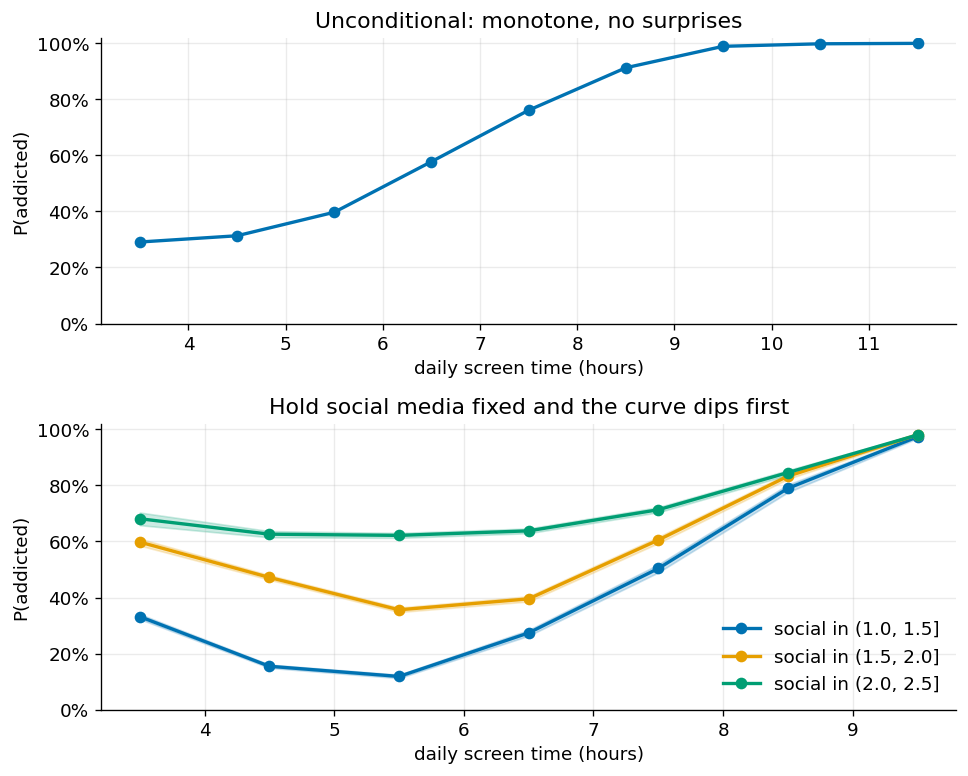

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(8.2, 6.6))
mids = (EDGES[:-1] + EDGES[1:]) / 2
axes[0].plot(mids, uncond["mean"], "o-", color=BLUE, lw=2)
axes[0].set_title("Unconditional: monotone, no surprises")

for (lo_s, hi_s), col in zip(BANDS, [BLUE, ORANGE, GREEN]):
    d = dip[dip.social == f"({lo_s}, {hi_s}]"]
    axes[1].plot(d.daily_mid, d["P(y=1)"], "o-", color=col, lw=2,
                 label=f"social in ({lo_s}, {hi_s}]")
    axes[1].fill_between(d.daily_mid, d.lo, d.hi, color=col, alpha=.2)
axes[1].set_title("Hold social media fixed and the curve dips first")
axes[1].legend(frameon=False)

for ax in axes:
    ax.set_xlabel("daily screen time (hours)"); ax.set_ylabel("P(addicted)")
    ax.set_ylim(0, 1.02); ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout(); plt.show()

Shaded bands are 95% Wilson intervals, and `half A` / `half B` are the same cells computed on two
disjoint halves of the data. At social media 1.0 to 1.5 hours, P(addicted) falls from about 33% at three
to four hours of screen time to about 12% at five to six hours, then climbs back past 50% by eight
hours. The peak and trough intervals do not overlap. The dip itself is about 21 points deep, and the
largest disagreement between the two halves anywhere in the table is under 3 points, so the effect is
roughly an order of magnitude bigger than the noise around it. This is a shape, not a wobble.

It reads sensibly once you see it. Holding social media constant while daily screen time rises means
the extra hours went to work or study or a game, and by the mirror's own logic that is not
what the label is tracking. Only when the total gets large does volume take over.

The consequence for modelling is direct.

In [17]:
MONO_ON = THREE
def oof_auc_mono(seed, mono):
    p = {**PARAMS, "seed": seed}
    if mono:
        p["monotone_constraints"] = [1 if c in MONO_ON else 0 for c in FEATURES]
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    oof = np.zeros(len(y))
    for tr_i, va_i in skf.split(Xall, y):
        m = lgb.train(p, lgb.Dataset(Xall.iloc[tr_i], y[tr_i]), num_boost_round=ROUNDS)
        oof[va_i] = m.predict(Xall.iloc[va_i])
    return roc_auc_score(y, oof)

free = [oof_auc_mono(s, False) for s in SEEDS]
mono = [oof_auc_mono(s, True)  for s in SEEDS]
mt = pd.DataFrame({"free": free, "monotone on the 3 screen columns": mono},
                  index=[f"seed {s}" for s in SEEDS])
mt.loc["mean"] = mt.mean()
print(mt.round(5).to_string())
d = np.array(free) - np.array(mono)
print(f"\npaired difference per seed: {np.round(d, 5).tolist()}")
print(f"mean cost of the constraint: {d.mean():+.5f}   "
      f"(seed spread of one setting: {max(max(free)-min(free), max(mono)-min(mono)):.5f})")

           free  monotone on the 3 screen columns
seed 0  0.96213                           0.95883
seed 1  0.96216                           0.95875
seed 2  0.96219                           0.95873
mean    0.96216                           0.95877

paired difference per seed: [0.0033, 0.00341, 0.00346]
mean cost of the constraint: +0.00339   (seed spread of one setting: 0.00010)


The difference is paired: same folds, same seeds, same rounds, one flag changed. So it is measured
against the right ruler, and it is larger than the seed-to-seed spread of either setting on its own.

The lesson generalises past this competition. A monotone prior that looks obviously true on the
marginal plot can be false conditionally, and the conditional shape is the one a tree model uses.

## 7. Missingness tells you nothing about the target

Every column here has missing values, which invites the usual questions. Is it missing not at random?
Should the pattern be a feature? Is imputation worth the effort?

For this dataset the answer is unusually clean, and it is no.

In [18]:
miss = pd.DataFrame({
    "missing %": (train[FEATURES].isna().mean() * 100).round(2),
    "P(y=1) when missing": [train[TARGET][train[c].isna()].mean() for c in FEATURES],
    "P(y=1) when present": [train[TARGET][train[c].notna()].mean() for c in FEATURES],
}).assign(gap=lambda d: (d["P(y=1) when missing"] - d["P(y=1) when present"]))
miss[["P(y=1) when missing", "P(y=1) when present", "gap"]] = \
    miss[["P(y=1) when missing", "P(y=1) when present", "gap"]].round(4)

n_missing = train[FEATURES].isna().sum(axis=1)
print(f"AUC of 'how many columns are missing', on its own: "
      f"{auc_sym(train[TARGET], n_missing):.4f}")
print(f"largest gap between missing and present, across all twelve columns: "
      f"{miss['gap'].abs().max():.4f}")
print(f"overall P(y=1) = {train[TARGET].mean():.4f}\n")
miss.sort_values("missing %", ascending=False)

AUC of 'how many columns are missing', on its own: 0.5017
largest gap between missing and present, across all twelve columns: 0.0042
overall P(y=1) = 0.7094



,missing %,P(y=1) when missing,P(y=1) when present,gap
social_media_hours,19.38,0.7094,0.7094,-0.0000
gaming_hours,18.34,0.7105,0.7092,0.0013
weekend_screen_time,16.21,0.7107,0.7092,0.0015
daily_screen_time_hours,13.86,0.7113,0.7091,0.0022
app_opens_per_day,11.67,0.7128,0.7090,0.0038
notifications_per_day,9.78,0.7102,0.7093,0.0009
stress_level,7.98,0.7090,0.7095,-0.0005
work_study_hours,7.45,0.7106,0.7093,0.0013
sleep_hours,6.43,0.7134,0.7092,0.0042
academic_work_impact,6.40,0.7095,0.7094,0.0000


The count of missing columns ranks at about 0.502, and the largest gap any single column opens between
its missing rows and its present ones is 0.0042, against an overall positive rate of 0.709. Whatever
punched the holes did not consult the label.

That claim is narrower than it may look, and it sits next to a second one that sounds like its
opposite. ryota517 reports that missing rates differ between train and test, and they do,
by a lot. Worth measuring both, because together they resolve into something useful.

In [19]:
tr_m, te_m = train[FEATURES].isna(), test[FEATURES].isna()
drift = pd.DataFrame({"train missing %": tr_m.mean() * 100,
                      "test missing %": te_m.mean() * 100})
drift["difference, pp"] = drift["test missing %"] - drift["train missing %"]
pooled = (tr_m.sum() + te_m.sum()) / (len(train) + len(test))
se = np.sqrt(pooled * (1 - pooled) * (1 / len(train) + 1 / len(test))) * 100
drift["z"] = (drift["difference, pp"] / se).round(1)

vals = pd.DataFrame({"train mean": train[NUM].mean(), "test mean": test[NUM].mean()})
vals["difference"] = vals["test mean"] - vals["train mean"]
print("Observed values agree; missing rates do not.\n")
print(vals.round(4).to_string())
drift.round(3).sort_values("z")

Observed values agree; missing rates do not.

                         train mean  test mean  difference
age                         26.6154    26.6087     -0.0067
daily_screen_time_hours      7.6409     7.6408     -0.0001
social_media_hours           2.4710     2.4712      0.0002
gaming_hours                 1.4593     1.4577     -0.0016
work_study_hours             2.3670     2.3660     -0.0010
sleep_hours                  6.8043     6.8017     -0.0026
notifications_per_day      145.8949   145.7481     -0.1468
app_opens_per_day          102.6368   102.6562      0.0194
weekend_screen_time          9.4799     9.4746     -0.0053


,train missing %,test missing %,"difference, pp",z
app_opens_per_day,11.674,8.675,-2.999,-44.0
social_media_hours,19.381,15.996,-3.385,-39.8
daily_screen_time_hours,13.864,11.066,-2.799,-37.9
stress_level,7.977,6.624,-1.353,-23.3
weekend_screen_time,16.209,17.110,0.901,11.1
gender,4.199,4.796,0.597,13.3
gaming_hours,18.343,20.054,1.710,19.9
sleep_hours,6.434,7.578,1.145,20.7
notifications_per_day,9.775,11.549,1.774,26.6
work_study_hours,7.452,9.375,1.923,32.2


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

is_test = np.r_[np.zeros(len(train)), np.ones(len(test))]

Xm = pd.concat([tr_m, te_m]).astype(float).to_numpy()
pm = cross_val_predict(LogisticRegression(max_iter=1000), Xm, is_test, cv=3,
                       method="predict_proba", n_jobs=-1)[:, 1]

Xv = pd.concat([train[NUM], test[NUM]]).to_numpy()
keep = ~np.isnan(Xv).any(axis=1)
pv = cross_val_predict(LogisticRegression(max_iter=1000), Xv[keep], is_test[keep], cv=3,
                       method="predict_proba", n_jobs=-1)[:, 1]

print("Adversarial validation, train against test:")
print(f"  missing-value pattern only          AUC {roc_auc_score(is_test, pm):.5f}")
print(f"  observed values only, complete rows AUC {roc_auc_score(is_test[keep], pv):.5f}"
      f"   (n = {keep.sum():,})")

Adversarial validation, train against test:
  missing-value pattern only          AUC 0.56575
  observed values only, complete rows AUC 0.50100   (n = 435,486)


So: adversarial validation separates train from test, all of that separation lives in the missing
patterns, the observed values are indistinguishable, and the missing patterns carry nothing about the
target.

**The alarm is real and it is harmless.** An adversarial AUC near 0.57 normally starts a project:
reweight the training rows, drop the drifting features, resample toward the test distribution. Here
there is nothing to reweight toward, because the thing that differs is unrelated to what you are
predicting. Time saved is the result.

Practical reading: leave the missing values to LightGBM, which handles them natively, and spend the
imputation effort somewhere else. MICE will give you plausible numbers and no ranking gain.

## 8. A leak-free baseline and a submission

Nothing exotic. Five stratified folds, categoricals passed to LightGBM as categoricals, missing values
left alone, no target encoding and therefore nothing to leak. Out-of-fold predictions are kept and
saved, so a fork can blend against them without rerunning the folds.

The point of this section is working plumbing, not a competitive score. Sections 3 to 6 are the part
worth forking.

In [21]:
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
Xte = test[FEATURES].copy()
for c in CAT:
    Xte[c] = pd.Categorical(Xte[c], categories=Xall[c].cat.categories)

oof = np.zeros(len(train)); pred = np.zeros(len(test)); fold_auc = []
for k, (tr_i, va_i) in enumerate(skf.split(Xall, y), 1):
    m = lgb.train({**PARAMS, "seed": SEED}, lgb.Dataset(Xall.iloc[tr_i], y[tr_i]),
                  num_boost_round=ROUNDS)
    oof[va_i] = m.predict(Xall.iloc[va_i])
    pred += m.predict(Xte) / skf.get_n_splits()
    fold_auc.append(roc_auc_score(y[va_i], oof[va_i]))
    print(f"fold {k}  AUC {fold_auc[-1]:.5f}")

print(f"\nfold mean {np.mean(fold_auc):.5f} +- {np.std(fold_auc):.5f}")
print(f"OOF AUC   {roc_auc_score(y, oof):.5f}")

fold 1  AUC 0.96128
fold 2  AUC 0.96199
fold 3  AUC 0.96251
fold 4  AUC 0.96311
fold 5  AUC 0.96203

fold mean 0.96218 +- 0.00061
OOF AUC   0.96218


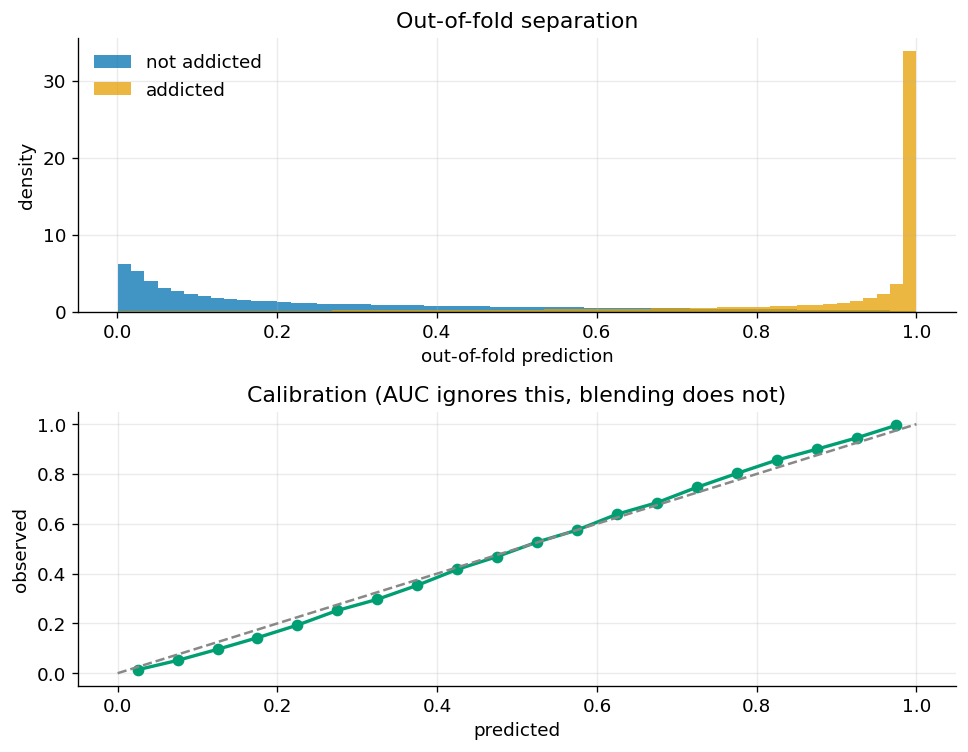

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(8.2, 6.4))
axes[0].hist(oof[y == 0], bins=60, alpha=.75, color=BLUE, label="not addicted", density=True)
axes[0].hist(oof[y == 1], bins=60, alpha=.75, color=ORANGE, label="addicted", density=True)
axes[0].set_xlabel("out-of-fold prediction"); axes[0].set_ylabel("density")
axes[0].set_title("Out-of-fold separation"); axes[0].legend(frameon=False)

bins = np.linspace(0, 1, 21)
idx = np.digitize(oof, bins) - 1
obs_rate = [y[idx == i].mean() if (idx == i).sum() > 200 else np.nan for i in range(20)]
axes[1].plot((bins[:-1] + bins[1:]) / 2, obs_rate, "o-", color=GREEN, lw=2)
axes[1].plot([0, 1], [0, 1], "--", color=GREY)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("observed")
axes[1].set_title("Calibration (AUC ignores this, blending does not)")
fig.tight_layout(); plt.show()

The two panels say different things and only one of them matters for the leaderboard. The separation
is wide, which is why the AUC is where it is. The calibration line sits close to the diagonal, which
AUC does not reward and never will, but a rank blend against someone else's out-of-fold file does:
two well-separated models that disagree about the probability scale blend worse than their AUCs suggest.

In [23]:
sub = pd.read_csv(os.path.join(DATA, "sample_submission.csv"))
sub[TARGET] = pred

assert len(sub) == len(test), "row count does not match the test set"
assert sub[ID].equals(test[ID]), "id column does not match the test set"
assert sub[TARGET].between(0, 1).all(), "predictions outside [0, 1]"
assert sub[TARGET].notna().all(), "missing predictions"

sub.to_csv("submission.csv", index=False)
np.save("oof.npy", oof)
print(f"submission.csv written: {len(sub):,} rows, "
      f"mean {sub[TARGET].mean():.4f}, "
      f"range [{sub[TARGET].min():.4f}, {sub[TARGET].max():.4f}]")
sub.head()

submission.csv written: 296,302 rows, mean 0.7093, range [0.0008, 1.0000]


,id,addicted_label
0,691369,0.997984
1,691370,0.960936
2,691371,0.962079
3,691372,0.984966
4,691373,0.996323


## 9. What a weak baseline does and does not inflate

Sections 3 and 4 were about a ruler that measures the wrong thing. This one is about a ruler that
measures the right thing against the wrong background.

Every delta published in this competition is measured against a different baseline, and the field has
caught it once with a number attached.
[tamerlanomralinov](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
measured a set of log-ratio budget features at +0.00036 on three folds and +0.00001 on ten, a thirty-six
fold collapse. The explanation given there: with 90% of the data instead of 67%, the trees find the
same relationships by splitting.

Capacity is the obvious second axis and I have no published measurement of it to point at, so the cell
below moves it together with the encoding and reports the pair rather than claiming the split. My
expectation going in was a collapse of the same order as the fold-count one.

Two references run on identical folds. The weak one is the twelve raw columns at 63
leaves and 400 rounds. The strong one adds value-level target encoding **and** raises capacity to 255
leaves and 1500 rounds, so it moves two axes at once; the split between them is stated after the
table. Value-level encoding encodes a column's exact value rather than its magnitude, picking up the
grid the generator rounded onto. The measurement is
[tomasa2](https://www.kaggle.com/code/tomasa2/s6e8-what-moved-the-score-and-what-didn-t)'s, at +0.0023
CV, and is explicit that the idea came from a public notebook by OMID BAGHCHEH SARAEI rather than from
an independent search. tamerlanomralinov ships it as value-level target encoding.

Then the same two columns are added to both references, and a placebo runs alongside as the floor.

In [24]:
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb

FOLD_SEED, SMOOTH, INNER = 42, 10.0, 5
WEAK   = dict(objective="binary", metric="auc", learning_rate=.05, num_leaves=63,
              min_data_in_leaf=200, feature_fraction=.9, bagging_fraction=.9,
              bagging_freq=1, verbosity=-1, seed=0)
STRONG = dict(objective="binary", metric="auc", learning_rate=.03, num_leaves=255,
              min_data_in_leaf=100, feature_fraction=.8, bagging_fraction=.8,
              bagging_freq=1, verbosity=-1, seed=0)
def value_te(tr_df, va_df, y_tr, cols):
    # Out-of-fold on both sides: validation rows use the whole training part, training rows
    # use an inner split that excludes them, so no row is ever encoded with its own label.
    prior = y_tr.mean()
    A, B = pd.DataFrame(index=range(len(tr_df))), pd.DataFrame(index=range(len(va_df)))
    inner = list(StratifiedKFold(INNER, shuffle=True, random_state=0).split(tr_df, y_tr))
    for c in cols:
        kt, kv = tr_df[c].astype("object"), va_df[c].astype("object")
        g = (pd.DataFrame({"k": kt.values, "y": y_tr})
         .groupby("k")["y"].agg(["sum", "count"]))
        full = (g["sum"] + prior * SMOOTH) / (g["count"] + SMOOTH)
        B["te_" + c] = kv.map(full).astype(float).fillna(prior).to_numpy()
        col = np.full(len(tr_df), np.nan)
        for a, b in inner:
            gi = (pd.DataFrame({"k": kt.values[a], "y": y_tr[a]})
                  .groupby("k")["y"].agg(["sum", "count"]))
            ei = (gi["sum"] + prior * SMOOTH) / (gi["count"] + SMOOTH)
            col[b] = kt.iloc[b].map(ei).astype(float).fillna(prior).to_numpy()
        A["te_" + c] = col
    return A, B
d, sm_, g_, w_ = train[DST], train[SM], train["gaming_hours"], train["work_study_hours"]
COMP = train[[SM, "gaming_hours", "work_study_hours"]]
extra = {
    "slack":      (d - COMP.fillna(0).sum(1)).to_numpy(float),
    "n_comp_obs": COMP.notna().sum(1).to_numpy(float),
    "placebo":    (pd.Series(np.random.default_rng(7).normal(size=len(train)))
                   .where(sm_.isna()).to_numpy(float)),
}

Xb = train[FEATURES].copy()
for c in CAT:
    Xb[c] = Xb[c].astype("category")
y = train[TARGET].to_numpy()
splits = list(StratifiedKFold(5, shuffle=True, random_state=FOLD_SEED).split(Xb, y))

ARMS = {"base": [], "+slack": ["slack", "n_comp_obs"], "+placebo": ["placebo"]}
out = {r: {a: [] for a in ARMS} for r in ("weak", "strong")}

for ref, params, use_te, rounds in (("weak", WEAK, False, 400),
                                    ("strong", STRONG, True, 1500)):
    for a, b in splits:
        xa = Xb.iloc[a].reset_index(drop=True); xb = Xb.iloc[b].reset_index(drop=True)
        if use_te:
            ta, tb = value_te(train.iloc[a], train.iloc[b], y[a], FEATURES)
            xa = pd.concat([xa, ta], axis=1); xb = pd.concat([xb, tb], axis=1)
        for arm, cols in ARMS.items():
            x1, x2 = xa.copy(), xb.copy()
            for c in cols:
                x1[c] = extra[c][a]; x2[c] = extra[c][b]
            m = lgb.train(params, lgb.Dataset(x1, y[a]), num_boost_round=rounds)
            out[ref][arm].append(roc_auc_score(y[b], m.predict(x2)))
    print(f"{ref} reference done", flush=True)

rows = []
for ref in out:
    base = np.array(out[ref]["base"])
    for arm in ARMS:
        v = np.array(out[ref][arm]); dl = v - base
        rows.append({"reference": ref, "arm": arm, "mean OOF": v.mean(),
                     "vs base": dl.mean(), "folds positive": f"{int((dl>0).sum())}/5"})
gate = pd.DataFrame(rows)
inf = (gate.query("reference=='weak' and arm=='+slack'")["vs base"].iloc[0] /
       gate.query("reference=='strong' and arm=='+slack'")["vs base"].iloc[0])
print(f"\ninflation from using the weak reference: {inf:.2f}x")
gate.round(5)

weak reference done
strong reference done

inflation from using the weak reference: 1.36x


,reference,arm,mean OOF,vs base,folds positive
0,weak,base,0.96210,0.00000,0/5
1,weak,+slack,0.96307,0.00097,5/5
2,weak,+placebo,0.96210,0.00000,1/5
3,strong,base,0.96668,0.00000,0/5
4,strong,+slack,0.96740,0.00071,5/5
5,strong,+placebo,0.96667,-0.00002,3/5


The strong reference is worth about +0.0046 over the weak one, which is far more than any engineered
feature in this notebook and a fair summary of where this competition's score actually lives. Of that
+0.0046, a separate run splits roughly a third to the capacity change and two thirds to the encoding,
so the two axes this cell moves together are not equal partners.

The inflation is real but small: the weak reference overstates the feature by the factor the cell
prints, around 1.4, with the same sign on all five folds. My prediction had the direction right and
the magnitude badly wrong, and the magnitude was the whole point: I expected something like the
thirty-six-fold collapse tamerlanomralinov measured on fold count.

So the useful form of the lesson is narrower than "always use a strong baseline". A baseline starved
of folds demonstrably lies by an order of magnitude, on that measurement. One starved of features
inflates by less than half. **These are different failures and they do not deserve equal worry.**
A caution against my own conclusion, from my own data: at ten folds instead of five, on the strong
reference, this feature holds at +0.00073 against +0.00071. Whatever the fold count does to some
features, it does not do it to this one, and I have not tested enough features to know which case is
typical.

## 10. The blend, taken apart

The top of this leaderboard is not a model, it is an average. A shared library of 74 out-of-fold
prediction arrays ([szymonkapiski](https://www.kaggle.com/datasets/szymonkapiski/s6e8-oof-library-47-models),
one frozen five-fold split) is downloaded, weights are chosen by hill climbing on those same
out-of-fold rows, and the resulting AUC is published.

That last part looked wrong to me. The weights are picked to score well on the rows they are then
scored on, which is the same shape of mistake as tuning a threshold on the test set. I expected a
visible premium, growing with the number of members, because more members means more freedom to fit
noise.

Three estimates settle it: the naive one everyone reports, a nested one where each fold is scored
with weights that never saw it, and random weights from the same family as a floor.

In [25]:
# Machinery for sections 10 and 11, folded away because it is not the idea: a fast rank AUC,
# a rank transform so members on different scales average sensibly, and greedy hill climbing
# with replacement, which is what the public blends in this competition use.
def fast_auc(yy, s):
    o = np.argsort(s, kind="stable"); r = np.empty(len(s)); r[o] = np.arange(1, len(s) + 1)
    n1 = yy.sum(); return (r[yy == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(yy) - n1))

def to_rank(v):
    o = np.argsort(v, kind="stable"); r = np.empty(len(v), dtype=np.float32)
    r[o] = np.linspace(0, 1, len(v), dtype=np.float32); return r

def hill(P, yy, rows, n_iter=40, search=None):
    si = rows if search is None else search
    ys, cur = yy[si], np.zeros(len(si))
    counts = np.zeros(P.shape[0], dtype=int)
    for _ in range(n_iter):
        best, bj = -1, -1
        for j in range(P.shape[0]):
            a = fast_auc(ys, cur + P[j, si])
            if a > best: best, bj = a, j
        counts[bj] += 1; cur = cur + P[bj, si]
    return counts
LIB = None
for cand in ["/kaggle/input/s6e8-oof-library-47-models", "oof_lib"]:
    if os.path.isdir(os.path.join(cand, "oof")):
        LIB = cand
        break

if LIB is None:
    print("OOF library not attached; skipping section 10")
else:
    files = sorted(glob.glob(os.path.join(LIB, "oof", "oof_*.npy")))
    names = [os.path.basename(f)[4:-4] for f in files]
    man = (pd.read_csv(os.path.join(LIB, "manifest.csv"))
             .set_index("model")["oof_auc"].to_dict())
    P = np.stack([to_rank(np.load(f)) for f in files])
    solo = np.array([man.get(n_, 0) for n_ in names]); order = np.argsort(-solo)
    rng = np.random.default_rng(0)
    allrows = np.arange(len(y)); srch = rng.choice(allrows, 150_000, replace=False)
    folds = np.empty(len(y), int)
    for k, (_, b) in enumerate(splits): folds[b] = k

    res = []
    for size in (5, 10, 20, 40, len(files)):
        Ps = P[order[:size]]
        def blend_with(counts, cols=None):
            w = counts / counts.sum()
            block = Ps if cols is None else Ps[:, cols]
            return (w[:, None] * block).sum(0)

        naive = fast_auc(y, blend_with(hill(Ps, y, allrows, search=srch)))
        nested = np.zeros(len(y))
        for k in range(5):
            ti, vi = allrows[folds != k], allrows[folds == k]
            c = hill(Ps, y, ti, search=rng.choice(ti, 150_000, replace=False))
            nested[vi] = blend_with(c, vi)
        rnd = [fast_auc(y, blend_with(np.bincount(rng.integers(0, size, 40),
                                                  minlength=size)))
               for _ in range(10)]
        res.append({"members": size, "naive": naive, "nested (honest)": fast_auc(y, nested),
                    # eight decimals on purpose: rounded to five this column reads as all
                    # zeros and hides the trend the whole section turns on
                    "premium": round(naive - fast_auc(y, nested), 8),
                    "equal weights": fast_auc(y, Ps.mean(0)),
                    "random mean": float(np.mean(rnd)), "random sd": float(np.std(rnd))})
        print(f"  {size:>3} members done", flush=True)
    blend = pd.DataFrame(res).set_index("members")
    print(f"best single member: {solo[order[0]]:.5f}")
    prem = blend["premium"].to_numpy()
    print("premium, five to seventy-four members:")
    print("   " + "  ".join(f"{p:.7f}" for p in prem))
    print(f"monotone increasing on this draw: {bool(np.all(np.diff(prem) > 0))}")
    w10 = blend.loc[10, "naive"] - blend.loc[10, "equal weights"]
    lose = blend.loc[10, "equal weights"] - blend.loc[len(files), "equal weights"]
    print(f"\nwithin the ten-member library: weights are worth {w10:+.5f}")
    print(f"averaging all {len(files)} instead of the best ten costs {lose:.5f}, "
          f"{lose / w10:.0f} times more")

    # A stack fitted out of fold can give a member a NEGATIVE weight, which hill
    # climbing cannot, so it can use a bad model as a correction. Same folds.
    from sklearn.linear_model import LogisticRegression

    def nested_logit(cols):
        oof = np.zeros(len(y))
        for k in range(5):
            ti, vi = allrows[folds != k], allrows[folds == k]
            lr = LogisticRegression(max_iter=1000)
            lr.fit(P[cols][:, ti].T, y[ti])
            oof[vi] = lr.decision_function(P[cols][:, vi].T)
        return fast_auc(y, oof)

    lg_all, lg_ten = nested_logit(np.arange(len(files))), nested_logit(order[:10])
    print(f"\nnested logistic stack over all {len(files)}: {lg_all:.5f}")
    print(f"                     over the best ten: {lg_ten:.5f}")
    print(f"              equal-weighted best ten: "
          f"{blend.loc[10, 'equal weights']:.5f}")
    display(blend.drop(columns=["premium"]).round(5).assign(
        premium=blend["premium"].map(lambda v: f"{v:.7f}")))

    5 members done
   10 members done
   20 members done
   40 members done
   74 members done
best single member: 0.96881
premium, five to seventy-four members:
   0.0000008  0.0000117  0.0000139  0.0000093  0.0000122
monotone increasing on this draw: False

within the ten-member library: weights are worth +0.00012
averaging all 74 instead of the best ten costs 0.00192, 16 times more

nested logistic stack over all 74: 0.96963
                     over the best ten: 0.96939
              equal-weighted best ten: 0.96930


,naive,nested (honest),equal weights,random mean,random sd,premium
members,,,,,,
5,0.96924,0.96924,0.96908,0.96909,0.00006,0.0000008
10,0.96942,0.96941,0.96930,0.96927,0.00005,0.0000117
20,0.96947,0.96946,0.96922,0.96919,0.00007,0.0000139
40,0.96948,0.96948,0.96908,0.96905,0.00008,0.0000093
74,0.96948,0.96947,0.96738,0.96722,0.00095,0.0000122


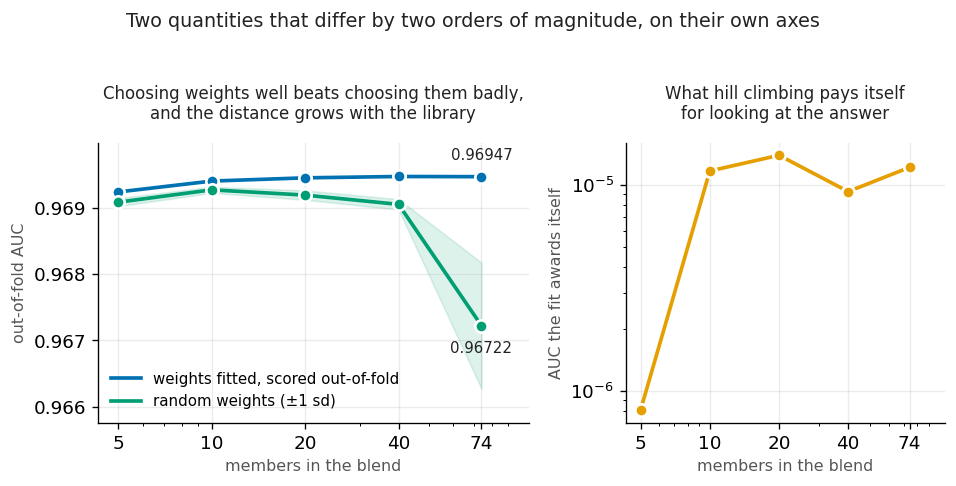

In [26]:
if LIB is not None:
    # Two quantities two orders of magnitude apart. Drawing the premium on the AUC axis would
    # make a caption point at a gap nobody can see, so it gets its own panel and its own scale.
    sizes = blend.index.to_numpy()
    nested_v, rmean, rsd = (blend["nested (honest)"].to_numpy(),
                            blend["random mean"].to_numpy(), blend["random sd"].to_numpy())
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.9), gridspec_kw={"width_ratios": [1.35, 1]})

    ax = axes[0]
    ax.fill_between(sizes, rmean - rsd, rmean + rsd, color=GREEN, alpha=.13, zorder=1)
    for vals, col in ((nested_v, BLUE), (rmean, GREEN)):
        ax.plot(sizes, vals, color=col, lw=2.2, zorder=3, solid_capstyle="round")
        dot(ax, sizes, vals, col, size=55)
    for vals, off in ((nested_v, 10), (rmean, -16)):
        ax.annotate(f"{vals[-1]:.5f}", xy=(sizes[-1], vals[-1]), xytext=(0, off),
                    textcoords="offset points", ha="center", fontsize=9, color=INK)
    ax.set_xscale("log"); ax.set_xticks(sizes); ax.set_xticklabels(sizes)
    ax.set_xlim(sizes.min() * .86, sizes.max() * 1.42); ax.margins(y=.16)
    ax.set_xlabel("members in the blend", fontsize=9.5, color=MUTED)
    ax.set_ylabel("out-of-fold AUC", fontsize=9.5, color=MUTED)
    ax.set_title("Choosing weights well beats choosing them badly,\n"
                 "and the distance grows with the library", fontsize=10, color=INK, pad=14)
    ax.legend([key(BLUE, marker=False), key(GREEN, marker=False)],
              ["weights fitted, scored out-of-fold", "random weights (±1 sd)"],
              frameon=False, loc="lower left", fontsize=9)

    ax = axes[1]
    ax.plot(sizes, blend["premium"], color=ORANGE, lw=2.2, zorder=3, solid_capstyle="round")
    dot(ax, sizes, blend["premium"], ORANGE, size=55)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(sizes); ax.set_xticklabels(sizes)
    ax.set_xlim(sizes.min() * .86, sizes.max() * 1.42)
    ax.set_xlabel("members in the blend", fontsize=9.5, color=MUTED)
    ax.set_ylabel("AUC the fit awards itself", fontsize=9.5, color=MUTED)
    ax.set_title("What hill climbing pays itself\nfor looking at the answer",
                 fontsize=10, color=INK, pad=14)
    fig.suptitle("Two quantities that differ by two orders of magnitude, on their own axes",
                 fontsize=11.5, color=INK, y=1.03)
    fig.tight_layout(); plt.show()

The premium is not zero, and that is the most that can be said for it: under a millionth at five
members, about a hundredth of a thousandth from ten up, and whether it grows with library size is the
boolean above, whose answer moves with the draw. **That the order depends on the draw is the finding.**
A quantity whose ranking changes when you resample the rows a search looked at is not one anybody
should be correcting a leaderboard score by. The mechanism is real, unmeasurable at this scale, and
irrelevant.

Two caveats, both pushing toward finding no premium, so they weaken my conclusion rather than prop it
up: the weights are hill-climbed on a fixed 150,000-row subsample for speed where published practice
fits on all out-of-fold rows and is more overfittable, and only the weights are re-fitted per fold, so
member selection is never nested here.

What the same table shows instead is a decomposition nobody seems to have printed. Within the
ten-member library:

- averaging the ten best members instead of taking the best one: worth about five ten-thousandths
- optimising the weights on top of that average: worth about a tenth of that again
- the dishonesty I went looking for: smaller still, a hundredth of the first step

Those three come off the table rather than out of this paragraph, because the last digit of each moves
with the draw and anything typed here would be stale by the next run. The order does not move.

The part that inverts the usual instinct is in the same table: **equal-weighting all seventy-four
members scores worse than equal-weighting the best ten**, and the cell prints that loss and how many
times larger it is than what weight tuning inside the ten is worth. It is more than an order of
magnitude, every time I have run it.

That is an argument against naive averaging, not against size, and the distinction matters because I
got it wrong first. The last line the cell prints settles it: a nested logistic stack over all
seventy-four, which can give a member a negative weight where hill climbing cannot, against the same
stack over the best ten, against the equal-weighted ten. Using everything wins; averaging everything
loses. Combining badly costs well over ten times what a weight mistake costs; combining well buys
about three times it. The order of magnitude is on the downside.

## 11. What the leaderboard is measuring today

The public board is scored on 20% of the test set, which is 59,260 rows. At an AUC near 0.971 the
Hanley and McNeil standard error on that many rows is 0.0006, which is larger than the gaps between
the top hundred teams. That looks like a board whose ordering is noise, and an earlier version of
this section said so.

It is not that simple, and the reason is section 10's own thesis. Two entries near the top are not two
independent measurements. They are both blends of the same public library, scored on the same rows, so
when you subtract one score from the other, part of the sampling noise is common and cancels.

How much cancels is the whole question, and it is not a constant. It depends on how much of the two
submissions is the same code, so no single pair can answer it. The table below measures seven, sorted
by how alike they are, from two near-identical single models down to the best single model against the
twentieth best.

Two things it keeps separate, because I had them confused. The correlation of the two prediction
vectors is not the correlation of the two AUC estimates across row draws, and only the second governs
the gap. And the rows being resampled are training rows scored by their out-of-fold predictions, at
the public and private sizes borrowed from the test set, because the test labels are not available.
That measures the row-sampling part of a split and nothing else.

In [27]:
# The standard error of an AUC on a given number of rows, from Hanley and McNeil (1982).
# Somebody else's formula rather than this notebook's idea, so it lives under the fold.
N_TEST, PUB, PI = len(test), 0.20, float(train[TARGET].mean())
n_pub, n_priv = int(N_TEST * PUB), N_TEST - int(N_TEST * PUB)

def hm_se(a, nn):
    npos, nneg = nn * PI, nn * (1 - PI)
    q1, q2 = a / (2 - a), 2 * a * a / (1 + a)
    return np.sqrt((a * (1 - a) + (npos - 1) * (q1 - a * a)
                    + (nneg - 1) * (q2 - a * a)) / (npos * nneg))
print(f"public {n_pub:,} rows, SE {hm_se(0.971, n_pub):.5f}   "
      f"private {n_priv:,} rows, SE {hm_se(0.971, n_priv):.5f}")

# Seven pairs spanning how much two submissions can have in common. Resample
# public and private-sized splits, and watch how far one entry moves against
# how far the gap between two of them moves.
if LIB is not None:
    top10, top20 = P[order[:10]].mean(0), P[order[:20]].mean(0)
    PAIRS = [
        ("best single vs 2nd best single",
         P[order[0]], P[order[1]]),
        ("top-8 vs top-10 (nested: 8 inside the 10)",
         P[order[:8]].mean(0), top10),
        ("evens vs odds of the top 20 (no shared member)",
         P[order[:20][::2]].mean(0), P[order[:20][1::2]].mean(0)),
        ("top-10 vs top-20", top10, top20),
        ("top-10 vs top-40", top10, P[order[:40]].mean(0)),
        ("top-10 vs all 74", top10, P.mean(0)),
        ("best single vs 20th best single",
         P[order[0]], P[order[19]]),
    ]
    rgen = np.random.default_rng(1)
    draws = []
    for _ in range(200):
        pb = rgen.choice(len(y), n_pub, replace=False)
        pv = rgen.choice(np.setdiff1d(np.arange(len(y)), pb), n_priv, replace=False)
        draws.append((pb, pv))

    rows = []
    for label, A, B in PAIRS:
        a1 = np.array([fast_auc(y[pb], A[pb]) for pb, _ in draws])
        a2 = np.array([fast_auc(y[pv], A[pv]) for _, pv in draws])
        b1 = np.array([fast_auc(y[pb], B[pb]) for pb, _ in draws])
        b2 = np.array([fast_auc(y[pv], B[pv]) for _, pv in draws])
        sd_move = float(np.std(a2 - a1))
        sd_gap = float(np.std((a2 - b2) - (a1 - b1)))
        rows.append({"pair": label,
                     "rho, predictions": np.corrcoef(A, B)[0, 1],
                     "rho, AUC estimates": np.corrcoef(a1, b1)[0, 1],
                     "sd of one move": sd_move,
                     "sd of the gap": sd_gap,
                     "gap steadier by": sd_move / sd_gap,
                     "resolvable at 95%": 1.96 * sd_gap})
    shake = pd.DataFrame(rows).sort_values("rho, AUC estimates", ascending=False)

public 59,260 rows, SE 0.00061   private 237,042 rows, SE 0.00031


In [28]:
if LIB is not None:
    SIX = ("sd of one move", "sd of the gap", "resolvable at 95%")
    FIVE = ("rho, predictions", "rho, AUC estimates")
    fmt = {c: shake[c].map("{:.6f}".format) for c in SIX}
    fmt.update({c: shake[c].map("{:.5f}".format) for c in FIVE})
    fmt["gap steadier by"] = shake["gap steadier by"].map("{:.0f}x".format)
    display(shake.assign(**fmt))

,pair,"rho, predictions","rho, AUC estimates",sd of one move,sd of the gap,gap steadier by,resolvable at 95%
0,best single vs 2nd best single,0.99999,0.99999,0.000729,0.000003,260x,0.000005
1,top-8 vs top-10 (nested: 8 inside the 10),0.99988,0.99987,0.000714,0.000011,64x,0.000022
2,evens vs odds of the top 20 (no shared member),0.99875,0.99701,0.000715,0.000054,13x,0.000106
3,top-10 vs top-20,0.99894,0.99577,0.000716,0.000065,11x,0.000128
4,top-10 vs top-40,0.99816,0.99391,0.000716,0.000079,9x,0.000155
5,top-10 vs all 74,0.99398,0.97386,0.000716,0.000172,4x,0.000337
6,best single vs 20th best single,0.98054,0.95432,0.000729,0.000218,3x,0.000428


In [29]:
# Typed in by hand, like section 12's board snapshots and nothing else in this notebook:
# the nine adjacent gaps in the public top ten, read off the downloadable board on
# 9 August 2026. A Kaggle kernel has no internet, so a live board cannot be computed here.
# precedent_boards.py in the repository reproduces these from the same file.
TOP10_GAPS_2026_08_09 = np.array([0.00008, 0.00002, 0.00001, 0.00001, 0.00002,
                                  0.00000, 0.00000, 0.00005, 0.00002])

In [30]:
if LIB is not None:
    # The algebra behind the table: a difference of two estimates with near-equal spread.
    chk = shake["sd of one move"] * np.sqrt(2 * (1 - shake["rho, AUC estimates"]))
    off = (chk / shake["sd of the gap"] - 1).abs().max() * 100
    print(f"sd(gap) = sd(move) * sqrt(2(1 - rho)) reproduces the measured "
          f"column to within {off:.0f}%")

    print("\nof the nine adjacent gaps in the public top ten on 9 Aug 2026, "
          "how many each pair could tell apart:")
    for _, r in shake.iterrows():
        n_ok = int((TOP10_GAPS_2026_08_09 > r["resolvable at 95%"]).sum())
        print(f"  {r['pair']:<46} resolves {r['resolvable at 95%']:.6f} -> {n_ok} of 9")
else:
    print("OOF library not attached, so this measurement did not run.")

sd(gap) = sd(move) * sqrt(2(1 - rho)) reproduces the measured column to within 5%

of the nine adjacent gaps in the public top ten on 9 Aug 2026, how many each pair could tell apart:
  best single vs 2nd best single                 resolves 0.000005 -> 7 of 9
  top-8 vs top-10 (nested: 8 inside the 10)      resolves 0.000022 -> 2 of 9
  evens vs odds of the top 20 (no shared member) resolves 0.000106 -> 0 of 9
  top-10 vs top-20                               resolves 0.000128 -> 0 of 9
  top-10 vs top-40                               resolves 0.000155 -> 0 of 9
  top-10 vs all 74                               resolves 0.000337 -> 0 of 9
  best single vs 20th best single                resolves 0.000428 -> 0 of 9


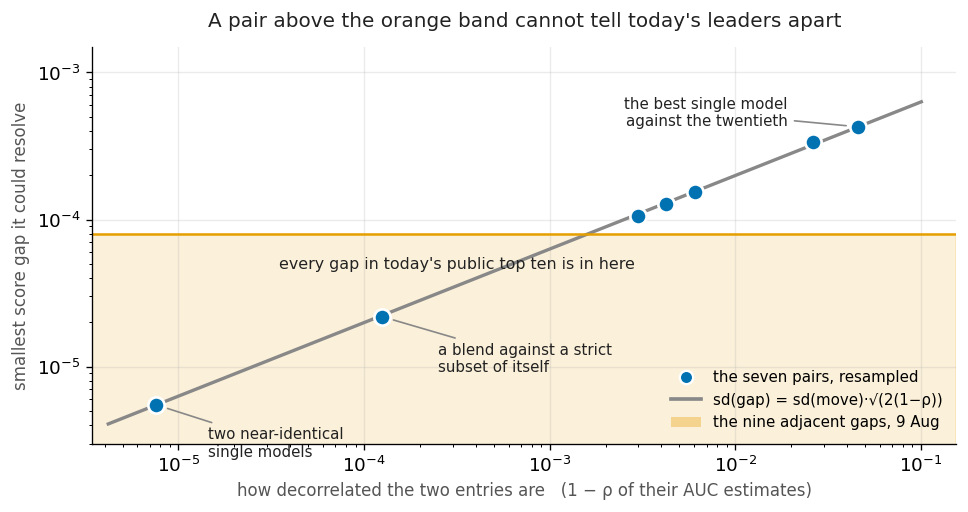

In [31]:
if LIB is not None:
    # Both axes are logs because rho runs from 0.95 to 0.99999 and the resolvable gap spans
    # two decades. On log-log the square-root law is a straight line, which is the point.
    xs = 1 - shake["rho, AUC estimates"].to_numpy()
    ys = shake["resolvable at 95%"].to_numpy()
    widest = TOP10_GAPS_2026_08_09.max()

    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    grid = np.logspace(np.log10(xs.min() * .55), np.log10(xs.max() * 2.2), 100)
    ax.plot(grid, 1.96 * shake["sd of one move"].mean() * np.sqrt(2 * grid),
            color=GREY, lw=2, zorder=2)
    ax.axhspan(1e-6, widest, color=ORANGE, alpha=.15, zorder=1)
    ax.axhline(widest, color=ORANGE, lw=1.5, zorder=2)
    dot(ax, xs, ys, BLUE, size=95)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(xs.min() * .45, xs.max() * 3.4); ax.set_ylim(3e-6, 1.5e-3)
    ax.set_xlabel("how decorrelated the two entries are   (1 − ρ of their AUC estimates)",
                  fontsize=10, color=MUTED)
    ax.set_ylabel("smallest score gap it could resolve", fontsize=10, color=MUTED)
    # Three of the seven are labelled, not all: a label on every point stops being a label.
    for lab, i, fx, fy, ha in (("two near-identical\nsingle models", 0, 1.9, .55, "left"),
                               ("a blend against a strict\nsubset of itself", 1, 2.0, .52, "left"),
                               ("the best single model\nagainst the twentieth", 6, .42, 1.25, "right")):
        ax.annotate(lab, xy=(xs[i], ys[i]), xytext=(xs[i] * fx, ys[i] * fy), fontsize=9,
                    color=INK, ha=ha, va="center",
                    arrowprops=dict(arrowstyle="-", color=GREY, lw=1, shrinkA=2, shrinkB=7))
    ax.annotate("every gap in today's public top ten is in here", xy=(3.5e-5, 5.0e-5),
                fontsize=9.5, color=INK, ha="left", va="center")
    ax.legend([key(BLUE), key(GREY, marker=False), Patch(facecolor=ORANGE, alpha=.35)],
              ["the seven pairs, resampled", "sd(gap) = sd(move)·√(2(1−ρ))",
               "the nine adjacent gaps, 9 Aug"], frameon=False, loc="lower right", fontsize=9)
    ax.set_title("A pair above the orange band cannot tell today's leaders apart",
                 fontsize=12, color=INK, pad=12)
    fig.tight_layout(); plt.show()

Everyone at the top moves, and they move together. A single entry's score swings between the boards
by the amount the cell prints as the sd of one move, around 0.0007, which is larger than the visible
gaps and is what makes the naive reading so tempting. The gap between two entries is steadier than
that. By how much is the part I got wrong.

Read the table by its last column. Two blends off the same shortlist, one a strict subset of the
other, tell apart differences of about 0.00002. Two blends of this library sharing no member need
about 0.0001. The best single model against the twentieth best needs about 0.0004, which is wider
than the whole span of the public top ten. The factor by which the gap beats the move runs from the
hundreds down to about three across that range. An earlier version of this section measured the
nested pair and wrote its factor down as a property of any two teams. It is a property of that pair.

The algebra is ordinary once both sides have near-equal spread: a difference of two estimates has
sd(gap) = sd(move) * sqrt(2(1 - rho)). The measured part is that it holds across the whole range,
which the cell checks. The useful part is the shape, and it is a square root, so it is gentler than
it looks: to double the noise in the gap you have to quadruple how decorrelated two submissions are.
Note also that sharing no member is not the same as being decorrelated. The evens-against-odds pair
shares nothing and is still steadier than two overlapping blends of different sizes.

So the reading has to be conditional, and the flat one I wrote here first was wrong in both
directions. The board is not a lottery between two entries that shopped the same shortlist. It is
still a lottery between a library blend and anything built differently, and, by the last block the
cell prints, between the public top ten as they actually sit. Their nine adjacent gaps run from 0.00008
down to nothing at all: two pairs of teams are tied. The downloadable board is rounded to five
decimals, so the small gaps here are not small, they are unmeasured. Read the last block the cell
prints against them. Only the steadiest pair in the table, two near-identical single models, tells
apart most of the nine. The nested pair manages two. Every pair below it, including two blends of
this same library that share no member, tells apart none of them at all.

What survives is the mechanism, and it is quantitative now rather than a hunch. Decorrelation is what
buys a shake-up, in either direction, and it is the only lever left on 31 August for anyone who wants
one. What does not survive is reading a small public gap as a real ordering. At the
correlation two real teams appear to have, none of this top ten's gaps is one.

It also does not tell you what will happen, and an earlier version of this notebook let it try. The
next section is the check I had not run.

## 12. What seven finished boards say

An earlier version of section 11 predicted that at least seven of the public top ten would hold their
places, and a later one that fewer than four would. Both numbers came out of the nested pair, which
section 11 finds is not even the steadiest pair in its own table, and neither had been put against a
board that finished.

Season 6 has seven of those. Both halves of each become downloadable once an episode closes, and I have
joined them into [a dataset](https://www.kaggle.com/datasets/georgymamarin/playground-series-s6-leaderboards) that is attached here, so this section computes its precedent
rather than quoting it. A longer walk through the same file, the parts about the season rather than
about this episode, is in [the companion notebook](https://www.kaggle.com/code/georgymamarin/three-of-seven-s6-boards-erased-the-public-top-ten).

In [32]:
# Recursive, because a dataset mount point is not a promise: match the file, not the folder.
BOARDS = next((os.path.dirname(h) for h in
               glob.glob("/kaggle/input/**/s6_leaderboards.csv", recursive=True)), None)
if BOARDS is None and os.path.exists("../s6_boards/dataset/s6_leaderboards.csv"):
    BOARDS = "../s6_boards/dataset"

if BOARDS is None:
    print("season leaderboards not attached, so this section did not run.")
else:
    lb  = pd.read_csv(os.path.join(BOARDS, "s6_leaderboards.csv"))
    eps = pd.read_csv(os.path.join(BOARDS, "s6_episodes.csv")).set_index("episode")
    lb = lb[~lb.is_host_baseline]        # rank 0 is the host's benchmark, not a competitor
    # S6E1 scores RMSE. Flip its sign so all seven episodes share one code path.
    SGN = {e: (1.0 if bool(eps.loc[e, "higher_is_better"]) else -1.0) for e in eps.index}

    rows = []
    for e, g in lb.groupby("episode"):
        top  = g[g.public_rank <= 10]
        move = SGN[e] * (top.private_score - top.public_score)
        span = (SGN[e] * top.public_score).max() - (SGN[e] * top.public_score).min()
        came = g.public_rank[g.private_rank <= 10]
        # A move shared by the whole top ten reorders nobody, so its SIZE cannot
        # be the mechanism. Moving differently from the chasers can.
        allmv = SGN[e] * (g.private_score - g.public_score)
        chase = allmv[(g.public_rank > 100) & (g.public_rank <= 300)].mean()
        rows.append({"episode": e, "metric": eps.loc[e, "metric"].replace(" Score", ""),
                     "teams": len(g),
                     "kept of its top ten": int((top.private_rank <= 10).sum()),
                     "the private top ten came from":
                         f"public {came.min():.0f}-{came.max():.0f}",
                     "vs its chasers, in scatters": (move.mean() - chase) / move.std(),
                     "span / scatter": span / move.std()})
    prec = pd.DataFrame(rows)
    kept = prec["kept of its top ten"]
    WIPED, HELD = list(prec.episode[kept == 0]), list(prec.episode[kept > 0])

In [33]:
if BOARDS is not None:
    display(prec.assign(**{
        "vs its chasers, in scatters": prec["vs its chasers, in scatters"].map("{:+.1f}".format),
        "span / scatter": prec["span / scatter"].map("{:.2f}".format)}))

,episode,metric,teams,kept of its top ten,the private top ten came from,"vs its chasers, in scatters",span / scatter
0,S6E1,Root Mean Squared Error,4317,8,public 1-19,+1.7,4.64
1,S6E2,Roc Auc,4370,0,public 29-365,-2.1,1.52
2,S6E3,Roc Auc,4142,6,public 1-68,-0.2,4.94
3,S6E4,Balanced Accuracy,4315,5,public 2-536,+0.2,0.91
4,S6E5,Roc Auc,3022,8,public 1-14,+1.1,3.26
5,S6E6,Balanced Accuracy,2816,0,public 149-495,-3.3,2.22
6,S6E7,Balanced Accuracy,3355,0,public 63-450,-1.9,1.97


In [34]:
if BOARDS is not None:
    print(f"{kept.sum()} of 70 places kept. The seven counts are {sorted(kept)}: "
          f"never once between one and four.")

    for name, col in (("the top ten against its chasers", "vs its chasers, in scatters"),
                      ("the retired two-episode rule  ", "span / scatter")):
        w, h = prec[col][kept == 0], prec[col][kept > 0]
        sep = "separates" if w.max() < h.min() or h.max() < w.min() else "overlaps"
        print(f"{name}: wipeouts {w.min():+.2f} to {w.max():+.2f}, the rest "
              f"{h.min():+.2f} to {h.max():+.2f} -> {sep}")

    # How cheap is that empty middle? Price it against a null that respects how much boards
    # differ from EACH OTHER, not just coin-flip noise inside one board.
    from scipy.stats import betabinom
    pbar = kept.mean() / 10
    rho = float(np.clip((kept.var(ddof=0) / (10 * pbar * (1 - pbar)) - 1) / 9, .01, .99))
    a, b = pbar * (1 - rho) / rho, (1 - pbar) * (1 - rho) / rho
    mid = float(betabinom.pmf(np.arange(1, 5), 10, a, b).sum())
    # The empty middle is the 1-4 band. The bet below is a DIFFERENT event: it only loses
    # on 3 or 4, so it must be priced on those two outcomes, not on the whole band.
    bet = float(betabinom.pmf(np.array([3, 4]), 10, a, b).sum())
    print(f"\nnull: beta-binomial matched to the spread between boards, rho {rho:.2f}.")
    print(f"   one board lands in 1-4 with probability {mid:.2f}")
    print(f"   seven empty middles in a row is a {(1 - mid) ** 7:.2f} event")
    print(f"   betting 'at most two, or at least five' wins {1 - bet:.0%} "
          f"of the time on luck alone")
    print(f"   the null is fitted to these same seven counts, so it is a generous "
          f"null, not a strict one")

27 of 70 places kept. The seven counts are [0, 0, 0, 5, 6, 8, 8]: never once between one and four.
the top ten against its chasers: wipeouts -3.34 to -1.95, the rest -0.24 to +1.69 -> separates
the retired two-episode rule  : wipeouts +1.52 to +2.22, the rest +0.91 to +4.94 -> overlaps

null: beta-binomial matched to the spread between boards, rho 0.46.
   one board lands in 1-4 with probability 0.35
   seven empty middles in a row is a 0.05 event
   betting 'at most two, or at least five' wins 86% of the time on luck alone
   the null is fitted to these same seven counts, so it is a generous null, not a strict one


Three boards of seven erased their public top ten. Four kept five or more. None finished between one
and four. Before reading anything into that gap, price it. Under a null that respects how far boards
differ from each other, one board lands in the one-to-four band with probability 0.35, so seven empty
middles in a row is a one-in-twenty coincidence. That null is fitted to these same seven counts, which
makes it a generous one rather than a strict one, and the gap survives it anyway. What does not survive
is the bet built on it: "at most two, or at least five" loses only on 3 and 4, and those two outcomes
carry 0.14 between them, so the bet wins six times in seven on luck alone. The gap is worth something.
The bet on it is nearly free.

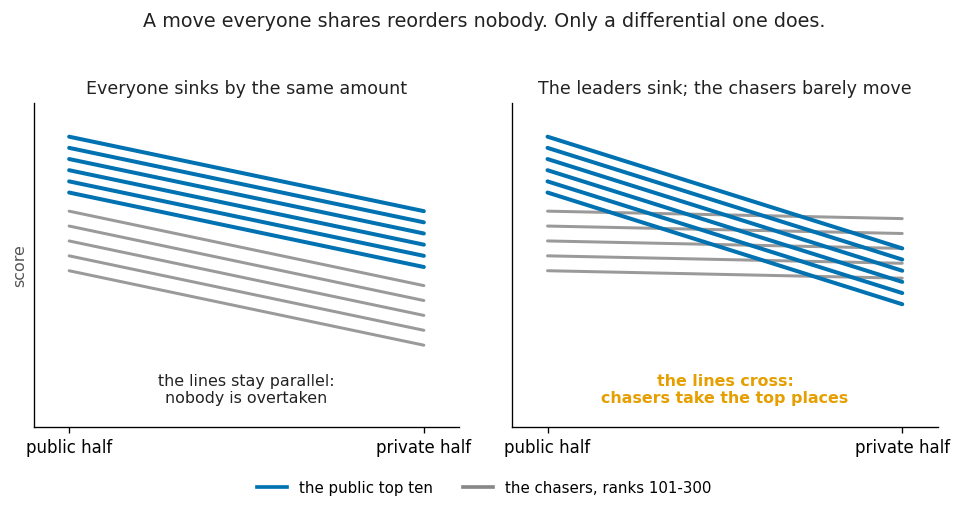

In [35]:
# A schematic, not a measurement: no data behind it, only the two shapes a split can have.
LEAD = np.array([0.86, 0.83, 0.80, 0.77, 0.74, 0.71])
CHASE = np.array([0.66, 0.62, 0.58, 0.54, 0.50])

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), sharey=True)
for ax, d_lead, d_chase, title in (
        (axes[0], -0.20, -0.20, "Everyone sinks by the same amount"),
        (axes[1], -0.30, -0.02, "The leaders sink; the chasers barely move")):
    for v in CHASE:
        ax.plot([0, 1], [v, v + d_chase], color=GREY, lw=1.8, alpha=.85, zorder=2,
                solid_capstyle="round")
    for v in LEAD:
        ax.plot([0, 1], [v, v + d_lead], color=BLUE, lw=2.4, zorder=3, solid_capstyle="round")
    # Room below the data for the captions: a label sitting on the lines is worse than no
    # label, and a white box behind it would paint over the very lines it describes.
    ax.set_xlim(-0.1, 1.1); ax.set_ylim(0.08, 0.95)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["public half", "private half"], fontsize=10)
    ax.set_yticks([]); ax.grid(visible=False)
    ax.set_title(title, fontsize=10.5, color=INK)
axes[0].set_ylabel("score", fontsize=9.5, color=MUTED)
axes[0].annotate("the lines stay parallel:\nnobody is overtaken", xy=(0.5, 0.145),
                 ha="center", fontsize=9.5, color=INK)
axes[1].annotate("the lines cross:\nchasers take the top places", xy=(0.5, 0.145),
                 ha="center", fontsize=9.5, color=ORANGE, fontweight="bold")
fig.legend([key(BLUE, marker=False), key(GREY, marker=False)],
           ["the public top ten", "the chasers, ranks 101-300"],
           frameon=False, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(.5, -.07))
fig.suptitle("A move everyone shares reorders nobody. Only a differential one does.",
             fontsize=11.5, color=INK, y=1.02)
fig.tight_layout(); plt.show()

The figure above took me two goes to arrive at. The first draft of this section had the mechanism as
how far the group travelled. Measured against the chasers instead, the seven split cleanly: every board
that wiped out sank between 1.9 and 3.4 of its own scatters against ranks 101 to 300, and no board that
held sank as much as a quarter of one. It needs the private half, so it explains rather than forecasts.

Section 11 built its rule on the size of that shared move instead: if a public top ten spans only about twice the
scatter of its own move, expect a wipeout. This file kills it. The rule fits six boards; the seventh is
S6E4 at 0.91, tighter than any wipeout, and it kept five of its ten. It fails in the expensive
direction, crying wipeout at a board that went on to hold.

That was ten teams. The same file answers the question for everybody else, and without a transfer
assumption: a move measured as a share of the field is dimensionless, so boards of different sizes pool.

In [36]:
if BOARDS is not None:
    # Named apart from section 6's EDGES so a forker who re-runs that plot after a full pass
    # does not get this list instead.
    BAND_EDGES = [0, .003, .01, .03, .10, .30, 1.0]
    LABELS = ["top 0.3%", "0.3-1%", "1-3%", "3-10%", "10-30%", "bottom 70%"]
    band = []
    for (lo, hi), lab in zip(zip(BAND_EDGES[:-1], BAND_EDGES[1:]), LABELS):
        v = pd.concat([(g[(g.public_rank > lo * len(g)) & (g.public_rank <= hi * len(g))]
                        .rank_delta.abs() / len(g)) for _, g in lb.groupby("episode")])
        band.append({"public band": lab, "teams": f"{len(v):,}",
                     "median move": f"{v.median() * 100:.2f}% of the field",
                     "nine times in ten, under": f"{v.quantile(.9) * 100:.1f}%",
                     "on a 3,000-team board": f"{v.median() * 3000:.0f} places, "
                                              f"tail {v.quantile(.9) * 3000:.0f}"})
    display(pd.DataFrame(band))

    tb = {e: (g[g.public_rank <= .003 * len(g)].rank_delta.abs() / len(g)).median()
          for e, g in lb.groupby("episode")}
    print(f"that same top band moved {min(tb[e] for e in WIPED) * 100:.0f}-"
          f"{max(tb[e] for e in WIPED) * 100:.0f}% of the field on the three "
          f"that wiped out,")
    print(f"and {min(tb[e] for e in HELD) * 100:.2f}-{max(tb[e] for e in HELD) * 100:.2f}% "
          f"on the four that held.")
else:
    print("season leaderboards not attached, so this measurement did not run.")

,public band,teams,median move,"nine times in ten, under","on a 3,000-team board"
0,top 0.3%,76,0.52% of the field,15.7%,"16 places, tail 470"
1,0.3-1%,185,5.68% of the field,16.7%,"170 places, tail 500"
2,1-3%,526,2.76% of the field,13.6%,"83 places, tail 409"
3,3-10%,"1,844",2.35% of the field,9.7%,"70 places, tail 291"
4,10-30%,"5,267",1.18% of the field,9.6%,"35 places, tail 287"
5,bottom 70%,"18,439",0.82% of the field,4.8%,"25 places, tail 143"


that same top band moved 11-14% of the field on the three that wiped out,
and 0.05-0.46% on the four that held.


The median is the boring half: a team in the top 0.3% of a public board finished about half a per cent
of the field from where it started. The ninth decile beside it says just under sixteen per cent, four
hundred and seventy places on a board of three thousand, and describes no board that has ever run.
That column is two populations, not one. The same band moved 11 to 14 per cent of the field on the
three that wiped out and 0.05 to 0.46 per cent on the four that held: twenty-four times apart at the
nearest edge, with nothing between. Quantiles of the pooled column are quantiles of that mixture, and
they describe the two kinds of board about as well as one average describes a bimodal distribution.

Which of the two kinds this board turns out to be decides most of what happens to you, and the thing
worth testing is whether that can be read while it is still running.

In [37]:
# Machinery for the cells below: how packed the top of a board is against a wider band, the
# separation test for a candidate split, and an enumeration of every way seven episodes
# divide three-and-four. Printed output tells the story; this is the arithmetic under it.
if BOARDS is not None:
    import itertools

    def packing(sc, rank, a, b, n=None):
        # a and b are shares of the field when n is given, team counts when it is not.
        ka, kb = (max(2, int(n * a)), int(n * b)) if n else (a, b)
        hi, lo = sc[rank <= ka], sc[rank <= kb]
        return (hi.max() - hi.min()) / (lo.max() - lo.min())

    EP = {e: ((SGN[e] * g.public_score).values, g.public_rank.values, len(g))
          for e, g in lb.groupby("episode")}
    ALL_SPLITS = list(itertools.combinations(sorted(EP), 3))

    def verdict(read):
        w, h = [read(e) for e in WIPED], [read(e) for e in HELD]
        return w, h, (max(w) < min(h) or max(h) < min(w))

    def splits_separated(pairs, as_share):
        found = set()
        for a, b in pairs:
            v = {e: packing(EP[e][0], EP[e][1], a, b, EP[e][2] if as_share else None) for e in EP}
            for trio in ALL_SPLITS:
                t = [v[e] for e in trio]
                r = [v[e] for e in sorted(EP) if e not in trio]
                if max(t) < min(r) or max(r) < min(t):
                    found.add(trio)
        return found
if BOARDS is not None:
    # Trap one: two free cut-points will separate almost anything. Sweep them instead of
    # reporting the pair that works.
    GRID = [.005, .0075, .01, .015, .02, .03, .05, .10, .15, .25, .40]
    SHARE_PAIRS = [(a, b) for i, a in enumerate(GRID) for b in GRID[i + 1:]]
    COUNT_PAIRS = [(a, b) for a in (5, 10, 15, 20, 30, 50)
                          for b in (50, 100, 150, 200, 300, 500, 1000) if b > a]
    for name, pairs, as_share in (("shares of the field", SHARE_PAIRS, True),
                                  ("team counts", COUNT_PAIRS, False)):
        n_sep = sum(verdict(lambda e, a=a, b=b: packing(EP[e][0], EP[e][1], a, b,
                                                        EP[e][2] if as_share else None))[2]
                    for a, b in pairs)
        print(f"bands as {name:>19}: {n_sep} of {len(pairs)} choices separate the three "
              f"wipeouts from the four holds")

    # The control: how many of the 35 arbitrary splits can the family separate?
    fam = splits_separated(SHARE_PAIRS, True) | splits_separated(COUNT_PAIRS, False)
    print(f"\nsweeping every band choice separates {len(fam)} of those "
          f"{len(ALL_SPLITS)} splits, {len(fam)/len(ALL_SPLITS):.0%} of them,")
    print("so a sweep that separates the real split is not evidence about anything.")
    print(f"and any single choice separates exactly 2 of the {len(ALL_SPLITS)} "
          f"by arithmetic,")
    print("the three lowest and the three highest, so that count is not evidence.")

bands as shares of the field: 10 of 55 choices separate the three wipeouts from the four holds
bands as         team counts: 16 of 41 choices separate the three wipeouts from the four holds

sweeping every band choice separates 21 of those 35 splits, 60% of them,
so a sweep that separates the real split is not evidence about anything.
and any single choice separates exactly 2 of the 35 by arithmetic,
the three lowest and the three highest, so that count is not evidence.


In [38]:
if BOARDS is not None:
    # What is not forced is WHICH two, and whether the real split is one of them.
    KEPT = dict(zip(prec.episode, kept))
    solo = sorted(EP, key=lambda e: packing(EP[e][0], EP[e][1], 10, 300))
    print("\ntop 10 / top 300, all seven in order:")
    for e in solo:
        print(f"   {e}  {packing(EP[e][0], EP[e][1], 10, 300):.3f}   kept {KEPT[e]}")
    print(f"the three wipeouts take the three lowest places: "
          f"one arrangement in {len(ALL_SPLITS)}.")
    print(f"   declared in advance that is p = {1 / len(ALL_SPLITS):.2f}")
    print(f"   picked out of a sweep, as this one was, "
          f"about {len(fam) / len(ALL_SPLITS):.1f}")


top 10 / top 300, all seven in order:
   S6E7  0.137   kept 0
   S6E6  0.349   kept 0
   S6E2  0.400   kept 0
   S6E3  0.550   kept 6
   S6E4  0.696   kept 5
   S6E5  0.721   kept 8
   S6E1  0.745   kept 8
the three wipeouts take the three lowest places: one arrangement in 35.
   declared in advance that is p = 0.03
   picked out of a sweep, as this one was, about 0.6


In [39]:
# The only measurements typed in by hand, along with section 11's nine gaps: a Kaggle
# kernel has no internet and a live board is not in any attached file, so these are read
# off the public board on the dates named. Both sets reproduce via precedent_boards.py.
LIVE = {"top 1% / top 10%": 0.639, "top 10 / top 300": 0.064}
N_LIVE = 1161
MATURITY = {"S6E8, 6 Aug 2026": (873, 0.051), "S6E8, 8 Aug 2026": (1062, 0.060),
            "S6E8, 9 Aug 2026": (N_LIVE, 0.064), "S6E7, 26 Jul 2026": (2854, 0.153),
            "S6E7, 29 Jul 2026": (3144, 0.130), "S6E7, 30 Jul 2026": (3164, 0.117),
            "S6E7, 1 Aug 2026, final": (3355, 0.137)}
DEPTH = 300 / N_LIVE

In [40]:
if BOARDS is not None:
    for label, a, b, as_share in (("top 1% / top 10%", .01, .10, True),
                                  ("top 10 / top 300", 10, 300, False)):
        def read(e, cut=None, a=a, b=b, as_share=as_share):
            sc, rank, n = EP[e]
            if cut:
                sc, rank, n = sc[rank <= cut], rank[rank <= cut], cut
            return packing(sc, rank, a, b, n if as_share else None)
        w, h, sep = verdict(read)
        wc, hc, sepc = verdict(lambda e: read(e, N_LIVE))
        print(f"\n{label}   (S6E8 on 9 Aug 2026 reads {LIVE[label]:.3f})")
        print(f"   the seven at full size : wipeouts {min(w):.3f}-{max(w):.3f}   "
              f"holds {min(h):.3f}-{max(h):.3f}   {'separates' if sep else 'OVERLAPS'}")
        print(f"   cut to {N_LIVE} teams      : wipeouts {min(wc):.3f}-{max(wc):.3f}   "
              f"holds {min(hc):.3f}-{max(hc):.3f}   {'separates' if sepc else 'OVERLAPS'}")
        if not as_share:
            print("      ^ cannot move: trimming the tail leaves ranks 1-300 alone")
            # Numerator stays a count, denominator becomes the depth it is here.
            def at_live_depth(e, a=a):
                sc, rank, n = EP[e]
                hi, lo = sc[rank <= a], sc[rank <= max(2, int(n * DEPTH))]
                return (hi.max() - hi.min()) / (lo.max() - lo.min())
            wd, hd, sepd = verdict(at_live_depth)
            print(f"   at the live DEPTH      : wipeouts {min(wd):.3f}-{max(wd):.3f}   "
                  f"holds {min(hd):.3f}-{max(hd):.3f}   "
                  f"{'separates' if sepd else 'OVERLAPS'}")
            print(f"      ^ rank 300 is the top {DEPTH * 100:.0f}% here, "
                  f"the top 7-11% on a full board")

    print("\nand how the count ruler drifts as a board fills "
          "(top 10 / top 300, snapshots):")
    for k, (n, v) in MATURITY.items():
        print(f"   {k:<26} {n:>5} teams   {v:.3f}")


top 1% / top 10%   (S6E8 on 9 Aug 2026 reads 0.639)
   the seven at full size : wipeouts 0.145-0.403   holds 0.459-0.953   separates
   cut to 1161 teams      : wipeouts 0.635-0.889   holds 0.721-0.850   OVERLAPS

top 10 / top 300   (S6E8 on 9 Aug 2026 reads 0.064)
   the seven at full size : wipeouts 0.137-0.400   holds 0.550-0.745   separates
   cut to 1161 teams      : wipeouts 0.137-0.400   holds 0.550-0.745   separates
      ^ cannot move: trimming the tail leaves ranks 1-300 alone
   at the live DEPTH      : wipeouts 0.042-0.138   holds 0.053-0.094   OVERLAPS
      ^ rank 300 is the top 26% here, the top 7-11% on a full board

and how the count ruler drifts as a board fills (top 10 / top 300, snapshots):
   S6E8, 6 Aug 2026             873 teams   0.051
   S6E8, 8 Aug 2026            1062 teams   0.060
   S6E8, 9 Aug 2026            1161 teams   0.064
   S6E7, 26 Jul 2026           2854 teams   0.153
   S6E7, 29 Jul 2026           3144 teams   0.130
   S6E7, 30 Jul 2026         

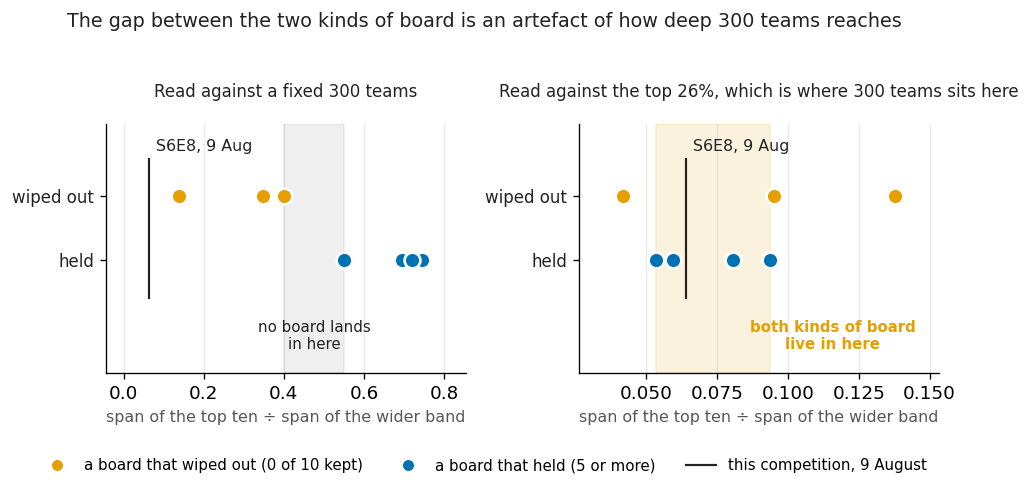

In [41]:
if BOARDS is not None:
    # The same seven boards, the same ruler, read two ways. Left: 300 teams as a count.
    # Right: 300 teams as the share of the field it is on this board. One panel has a gap.
    def _depth_read(e):
        # Numerator a team count, denominator a share: packing() cannot mix the two.
        sc, rank, n = EP[e]
        hi, lo = sc[rank <= 10], sc[rank <= max(2, int(n * DEPTH))]
        return (hi.max() - hi.min()) / (lo.max() - lo.min())

    full_r = {e: packing(EP[e][0], EP[e][1], 10, 300) for e in EP}
    depth_r = {e: _depth_read(e) for e in EP}

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.5))
    for ax, vals, title in (
            (axes[0], full_r, "Read against a fixed 300 teams"),
            (axes[1], depth_r,
             f"Read against the top {DEPTH*100:.0f}%, which is where 300 teams sits here")):
        hi_w, lo_h = max(vals[e] for e in WIPED), min(vals[e] for e in HELD)
        if lo_h > hi_w:
            ax.axvspan(hi_w, lo_h, color=GREY, alpha=.13, zorder=1)
            ax.annotate("no board lands\nin here", xy=((hi_w + lo_h) / 2, 0.30),
                        ha="center", va="center", fontsize=9, color=INK)
        else:
            ax.axvspan(max(min(vals[e] for e in HELD), min(vals[e] for e in WIPED)),
                       min(hi_w, max(vals[e] for e in HELD)), color=ORANGE, alpha=.13, zorder=1)
            ax.annotate("both kinds of board\nlive in here",
                        xy=(max(vals.values()) * .84, 0.30), ha="center", va="center",
                        fontsize=9, color=ORANGE, fontweight="bold")
        dot(ax, [vals[e] for e in WIPED], [1.62] * len(WIPED), ORANGE)
        dot(ax, [vals[e] for e in HELD], [1.02] * len(HELD), BLUE)
        live = LIVE["top 10 / top 300"]
        ax.axvline(live, color=INK, lw=1.3, zorder=5, ymin=.30, ymax=.86)
        lo_all, hi_all = min(min(vals.values()), live), max(max(vals.values()), live)
        pad = (hi_all - lo_all) * .16
        ax.set_xlim(lo_all - pad, hi_all + pad)
        near_left = (live - lo_all) / (hi_all - lo_all) < .3
        ax.annotate("S6E8, 9 Aug", xy=(live, 2.02), ha="left" if near_left else "center",
                    va="bottom", fontsize=9.5, color=INK,
                    xytext=(4 if near_left else 0, 0), textcoords="offset points")
        ax.set_ylim(-0.05, 2.3); ax.set_yticks([1.62, 1.02])
        ax.set_yticklabels(["wiped out", "held"], fontsize=10, color=INK)
        ax.set_xlabel("span of the top ten ÷ span of the wider band", fontsize=9.5, color=MUTED)
        ax.set_title(title, fontsize=10, color=INK, pad=16)
        ax.grid(axis="y", visible=False)
    fig.legend([key(ORANGE), key(BLUE), Line2D([], [], color=INK, lw=1.3)],
               ["a board that wiped out (0 of 10 kept)", "a board that held (5 or more)",
                "this competition, 9 August"],
               frameon=False, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(.5, -.10))
    fig.suptitle("The gap between the two kinds of board is an artefact of how deep "
                 "300 teams reaches", fontsize=11.5, color=INK, y=1.03)
    fig.tight_layout(); plt.show()

Both rulers fail, and they fail for different reasons.

The share-of-the-field ruler dies under the cut. Trim the seven finished boards to 1,161 teams, the
size of this field on 9 August, and wipeouts and holds land on top of each other; this board's 0.639
sits inside what a wiped-out board reads once it is cut to this size. On a board this young that
reading is worth nothing, and reading the packing at the top is what all of us do while we wait.

The team-count ruler looked like the survivor and is not. It comes through the cut unchanged, and I
first wrote that down as evidence. It is not evidence: trimming the tail leaves ranks 1 to 300
untouched, so the number *cannot* move, and a statistic that is immune to a test by construction has
not passed it. Its real exposure is depth. Rank 300 is a quarter of the way down this board and between
a fourteenth and a ninth of the way down a finished one, so 0.064 and 0.137 are not the same measurement.
Read the seven at the depth rank 300 actually is here and the separation is gone, with this board
sitting inside both ranges at once.

The sweep cannot rescue it either. Sixteen separating choices out of forty-one reads as a strong result
and is not one: seven episodes split three-and-four thirty-five ways, and this family of rulers, swept
freely, separates twenty-one of them. Nor is "it separates two of the thirty-five" the badge I first
took it for. For any seven distinct numbers exactly two splits are separable, the three lowest and the
three highest, so that count is arithmetic. What is not arithmetic is that the three wipeouts take the
three lowest places, one arrangement in thirty-five: pre-registered that would be worth 0.03, but
chosen after sixteen pairs that already worked it is worth about what the sweep is, which is 0.6.

So I have no ruler I can validate on a board at a third of its size. The quantity that does separate
the seven is in this section's first table, the top ten against its chasers.

### The prediction, rewritten

Written before the split so it can be scored after it, against the *final* public leaderboard rather
than the 9 August snapshot above.

1. **At most two of the public top ten will be in the private top ten, or at least five. Three or four
   and I am wrong.** This is the half I would defend, and by the pricing above it is also close to a
   free bet, won six times in seven by anyone who guesses. Both are true and neither cancels the other.
2. **On which side, I have no call.** The version of this section published before this one named the
   wipeout, and the depth control above took it away: the ruler that call rested on cannot be read at
   this field size. What would give me a call is the final board, where the depth problem disappears
   because the field is full: the same ruler, against 0.137 to 0.400 for the wipeouts and 0.550 to
   0.745 for the holds. A measurement for 31 August, not for today.
3. **Carried over from the earlier version, and still conditional on size.** If the field finishes near
   its predecessors', around three thousand teams, the private top ten will contain at least one entry
   from outside the public top hundred. That happened on four of the seven, and on two of the three
   boards that finished near that size.

None of this replaces section 11. Decorrelation is still the only lever on the row-sampling part of a
split and that arithmetic is untouched. What this section adds is that all three wipeouts show a
systematic differential between the top ten and its chasers, which row sampling on its own would not
produce. What changed is what the notebook may claim about the future on the strength of any of it,
and this month the answer came out smaller than last week's.

## 13. Design choices and limitations

### **Where the measurements could not look**

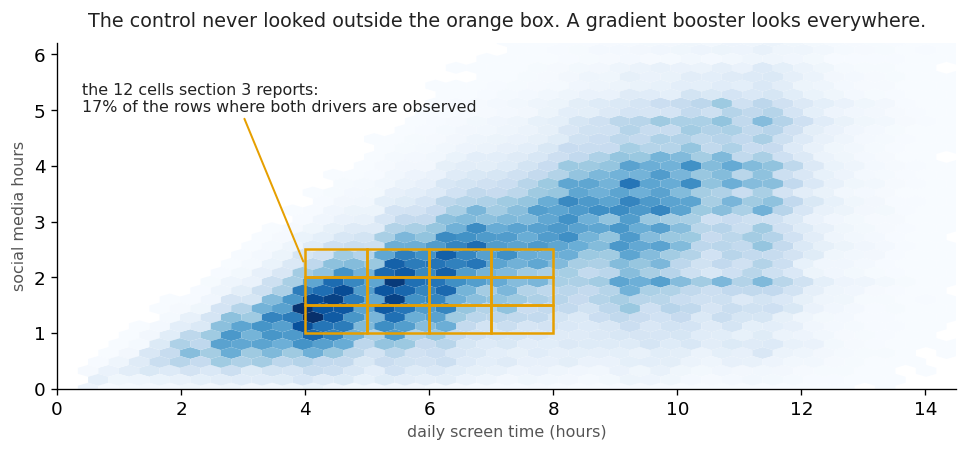

In [42]:
# The limitation of section 3, drawn: where the reported cells sit inside the data they sample.
# The cloud is every row with both drivers present; the boxes are the cells section 3 kept.
cloud = train[both]
fig, ax = plt.subplots(figsize=(8.2, 3.9))
ax.hexbin(cloud[DST], cloud[SM], gridsize=44, cmap="Blues", mincnt=1, linewidths=0)
for _, c in cond.iterrows():
    lo_d, hi_d = (float(v) for v in c.daily.strip("(]").split(", "))
    lo_s, hi_s = (float(v) for v in c.social.strip("(]").split(", "))
    ax.add_patch(Rectangle((lo_d, lo_s), hi_d - lo_d, hi_s - lo_s, fill=False,
                           edgecolor=ORANGE, lw=1.5, zorder=5))
ax.set_xlim(0, 14.5); ax.set_ylim(0, 6.2); ax.grid(visible=False)
ax.set_xlabel("daily screen time (hours)", fontsize=9.5, color=MUTED)
ax.set_ylabel("social media hours", fontsize=9.5, color=MUTED)
# The share section 4b quotes, from the same two numbers: rows inside the reported cells over
# rows with both drivers present. Boxes are wider than that, because a cell also needs the four
# other columns present, and a fifth of its rows do not have them.
share = 100 * cond.n.sum() / both.sum()
ax.annotate(f"the {len(cond)} cells section 3 reports:\n{share:.0f}% of the rows where "
            f"both drivers are observed",
            xy=(0.4, 5.5), fontsize=9.5, color=INK, ha="left", va="top")
ax.annotate("", xy=(4.0, 2.2), xytext=(3.0, 4.9),
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1.2, shrinkA=2, shrinkB=3))
ax.set_title("The control never looked outside the orange box. "
             "A gradient booster looks everywhere.", fontsize=11.5, color=INK, pad=10)
fig.tight_layout(); plt.show()

**The section 3 control is blind to combinations, and that is structural.** Section 4c is a worked
example of it missing the feature that mattered most. It is blind to most of the data as well, as the
figure shows: the twelve cells sample one window in the middle, and the whole right-hand region is
somewhere the control never entered. Read a 0.500 there as "no signal alone", never as "nothing to
build here".

**The conditioning cells are one hour by half an hour**, sized so every reported cell holds at least
500 rows. Section 3 says which way leftover variation inside a cell cuts.

**The ablation uses one model family and one schedule.** Seeds bound the noise of the estimate, not the
choice of LightGBM. The section 4 table and the full-model comparison in 4c average three seeds; the
two diagnostic splits, in 4b and 4c, average two, which is thinner and worth knowing when you read the
"about two thirds". A different inductive bias might extract something from the nine columns.

**The monotone experiment constrains three columns.** Constraining only daily screen time, or adding
other columns, would give different numbers. The paired design keeps the comparison fair; it does not
make it exhaustive.

### **What this notebook takes on trust**

**The mirror is a candidate, not a proven source**, as section 5 says at length. The competition-side
conclusions (the collapse under conditioning, the ablation, the constraint, the dip) are all measured
on competition data and stand without it.

**The card at the top is not printed by a cell.** Section 4 carries the `three + gaming` arm it quotes
and prints both halves of its ratio on one line, so the card is checkable against the table rather
than against a run you cannot see. It is still a separate image, so a rerun can leave it stale: trust
the cells over the card.

**Sections 11 and 12 read a live board from typed numbers, both off the 9 August 2026 download.** The
seven finished episodes are computed from the attached dataset; a running board cannot be attached and
the notebook has no internet. They are the only two measurements here that are typed in rather than
computed, both dated where they sit and both reproduced by `precedent_boards.py` in the repository.
They stale faster than anything else in the notebook.

### **What none of this is about**

**Nothing here is calibrated for a probability-scored metric.** AUC is rank-only, so the baseline is
not tuned for Brier or log-loss, and the calibration panel is diagnostic.

**None of this is about smartphones or people.** These rows came out of a generator trained on a small
file of unknown provenance. The relationships are properties of that pipeline. Nothing in this notebook
supports a claim about screen time and addiction in the world.

## 14. What to read next

- [**Kaggle Playground Leaderboards: Public + Private**](https://www.kaggle.com/datasets/georgymamarin/playground-series-s6-leaderboards), and
  [**Three of seven S6 boards erased the public top ten**](https://www.kaggle.com/code/georgymamarin/three-of-seven-s6-boards-erased-the-public-top-ten), both mine. The dataset is
  the file section 12 runs on: seven finished episodes, both halves of each board joined on team id.
  The notebook is the season-level version, and it stops short of where section 12 goes: it tests only
  share-of-the-field packing, kills four of its own claims along the way, and concludes you cannot
  tell in advance which kind of board you drew. Section 12 tried to get past that and did not.
- [**What Moved the Score, and What Didn't**](https://www.kaggle.com/code/tomasa2/s6e8-what-moved-the-score-and-what-didn-t)
  by tomasa2. Twenty ideas tried, one that paid, each with its number. Read it for the value-level
  encoding measurement that section 9 builds on.
- [**Lookup-Transformer + Insights**](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
  by tamerlanomralinov. The fold-count result section 9 leans on, plus a table of dead ends measured
  rather than guessed.
- [**Predicting Smartphone Addiction - EDA**](https://www.kaggle.com/code/pavloivanin/predicting-smartphone-addiction-eda)
  by Pavlo Ivanin. A clean, fast orientation to the columns if you are arriving cold.

### My two previous episodes, same playbook

<a href="https://www.kaggle.com/code/georgymamarin/s6e7-will-your-0-950-survive-the-private-split">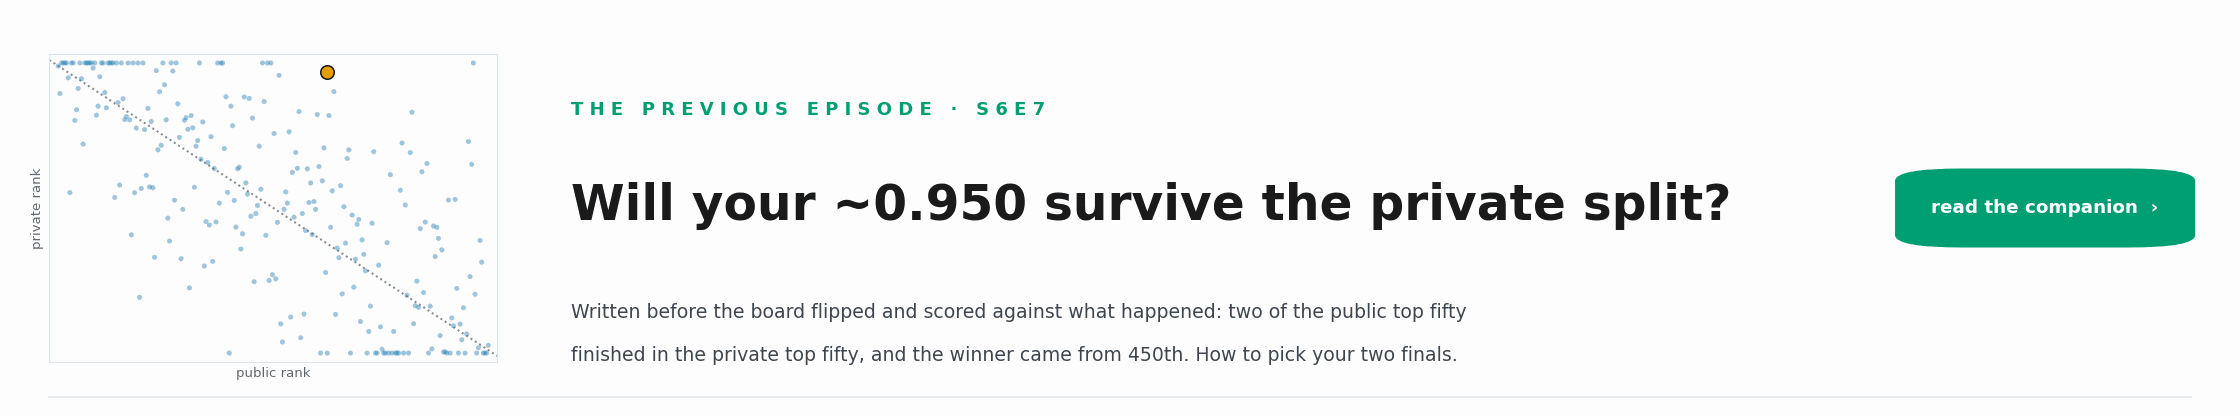</a>

**S6E7** was written before the board flipped and scored afterwards against what happened. Read it for
picking final submissions when the public board is mostly measuring noise, which by section 11 is a
question about how correlated the top entries are, and that episode's were not.

<a href="https://www.kaggle.com/code/georgymamarin/an-almost-exhaustive-stellar-class-eda-final">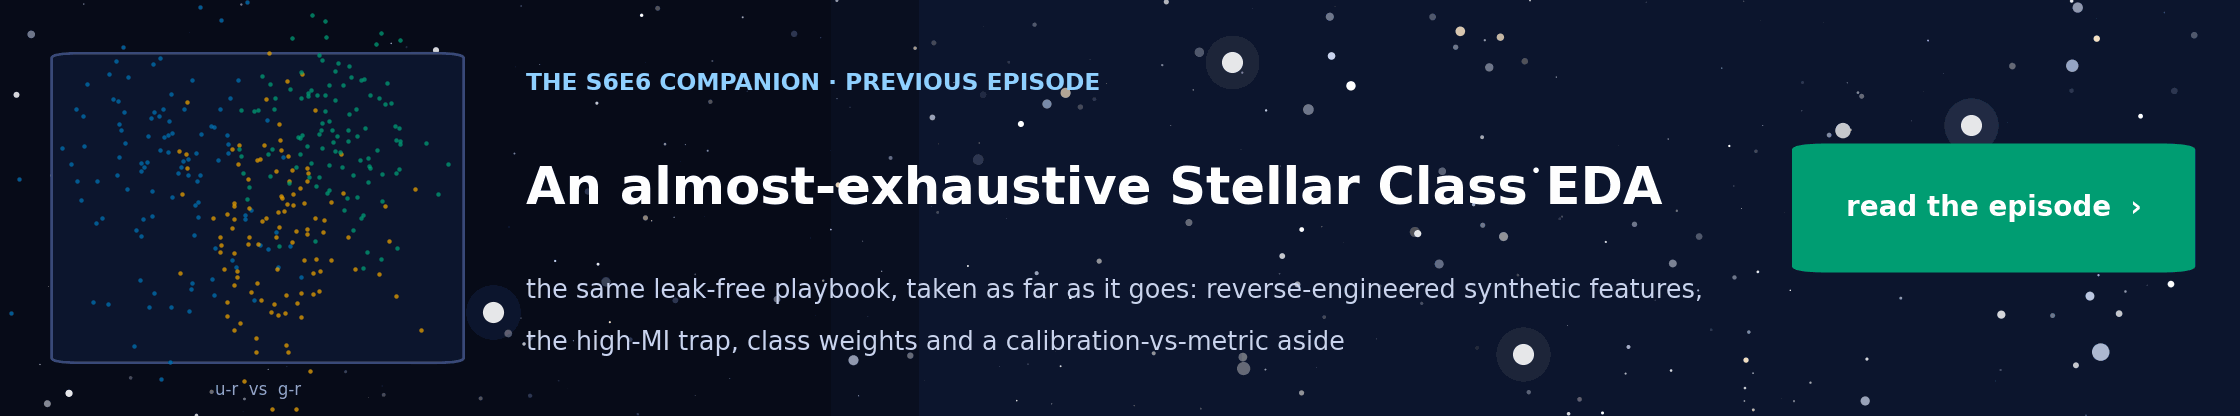</a>

**S6E6** is the long-form version of the leak-free CV method section 8 uses here, with every step
spelled out rather than compressed.

## Credits

Thanks to Kaggle and to Yao Yan, Walter Reade and Elizabeth Park for the series. To ryota517, whose
careful refusal to over-claim the source lineage set the standard section 5 tries to hold to, and who
published the budget constraint first; the account has since been deleted, so the link is gone but the
credit is not. tomasa2 and tamerlanomralinov both published the constraint independently in the days
after, and their notebooks are still up. To Dariush Afshar, whose residual feature is the whole of
section 4c. And to Muhammad Faheem, whose question in that thread is the one 4c ends up answering.

---

**If you fork this, take sections 3 and 4c together.** The conditional control is four lines and works
on any tabular competition; 4c is the reminder that it cannot see a feature assembled from several
columns at once. Either half alone would have misled me, and did. I would like to know whether the
pair changes your read of a feature table somewhere else.

Corrections are welcome, and I will publish them as corrections rather than editing the number and
moving on. That is not a posture: section 4c exists because someone answered a question this notebook
left open, and it went in with their name on it. If you can account for the third of the gap that is
still missing, say so in the comments and the same will happen.